# Analyse BlueSeis BSPF Events

In [24]:
import os
import obspy as obs
import matplotlib.pyplot as plt
import numpy as np

from obspy.clients.fdsn import Client

from functions.request_data import __request_data
from functions.compute_adr_pfo import __compute_adr_pfo
from functions.compute_beamforming_pfo import __compute_beamforming_pfo
from functions.get_event_info import __get_event_info
from functions.get_stream import __get_stream

In [25]:
if os.uname().nodename == 'lighthouse':
    root_path = '/home/andbro/'
    data_path = '/home/andbro/kilauea-data/'
    archive_path = '/home/andbro/freenas/'
    bay_path = '/home/andbro/ontap-ffb-bay200/'
    lamont_path = '/home/andbro/lamont/'
elif os.uname().nodename == 'kilauea':
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'
elif os.uname().nodename in ['lin-ffb-01', 'ambrym', 'hochfelln']:
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'

## Configurations

In [26]:
config = {}

# BSPF coordinates
config['sta_lon'] = -116.455439
config['sta_lat'] = 33.610643

# specify client
config['Client'] = Client("USGS")
config['Client'] = Client("IRIS")

# _____________________________________________
# Event M62
config['name'] = "M62"
config['tbeg'] = obs.UTCDateTime("2022-11-22 16:40:10")
config['tend'] = obs.UTCDateTime("2022-11-22 16:42:30")
config['trim'] = [0, 0]

# _____________________________________________
# Event M41
config['name'] = "M41"
config['tbeg'] = obs.UTCDateTime("2022-12-31 12:12:20")
config['tend'] = obs.UTCDateTime("2022-12-31 12:12:55")
config['trim'] = [5, 0]

# _____________________________________________
# Event M48
# config['name'] = "M48"
# config['tbeg'] = obs.UTCDateTime("2024-02-16 07:38:00")
# config['tend'] = obs.UTCDateTime("2024-02-16 07:40:00")
# config['trim'] = [15, 0]

# _____________________________________________
# Event M21
# config['name'] = "M21"
# config['tbeg'] = obs.UTCDateTime("2023-09-11 09:20:10")
# config['tend'] = obs.UTCDateTime("2023-09-11 09:20:30")
# config['trim'] = [7.5, 5]

# _____________________________________________
# Event M35
# config['name'] = "M35"
# config['tbeg'] = obs.UTCDateTime("2023-10-30 12:31:10")
# config['tend'] = obs.UTCDateTime("2023-10-30 12:32:10")
# config['trim'] = [29, 20]

# _____________________________________________
# Event M29
# config['name'] = "M29"
# config['tbeg'] = obs.UTCDateTime("2024-02-27 22:50:50")
# config['tend'] = obs.UTCDateTime("2024-02-27 22:51:20")
# config['trim'] = [5, 10]

# _____________________________________________
# checkup
# config['name'] = "check"
# config['tbeg'] = obs.UTCDateTime("2024-08-07 12:05:00")
# config['tend'] = obs.UTCDateTime("2024-08-07 12:10:00")
# config['trim'] = [0, 0]

# _____________________________________________
# Event M31
# config['name'] = "M31"
# config['tbeg'] = obs.UTCDateTime("2024-08-16 06:45:10")
# config['tend'] = obs.UTCDateTime("2024-08-16 06:47:10")
# config['trim'] = [0, 0]

# _____________________________________________
# Event M31
# config['name'] = "M31"
# config['tbeg'] = obs.UTCDateTime("2024-09-01 16:33:30")
# config['tend'] = obs.UTCDateTime("2024-09-01 16:34:30")
# config['trim'] = [0, 0]

# _____________________________________________
# Event M41
# config['name'] = "M41"
# config['tbeg'] = obs.UTCDateTime("2024-10-06 10:51:00")
# config['tend'] = obs.UTCDateTime("2024-10-06 10:53:00")
# config['trim'] = [20, 50]



# output path for figures
config['path_to_figs'] = data_path+f"BSPF/figures/{config['name']}_event/"

# define path to data
config['path_to_data'] = f"./data/event{config['name']}_6c.mseed"

## Load Data

In [27]:
from functions.get_event_info import __get_event_info

In [29]:
# config, dist, baz, az = __get_event_info(config, min_mag=float(config['name'][1])-0.5)

### Download Waveforms

In [30]:
def __get_stream(tbeg, tend, status=False):

    from functions.request_data import __request_data
    from functions.compute_adr_pfo import __compute_adr_pfo
    from obspy import UTCDateTime

    tbeb, tend = UTCDateTime(tbeg), UTCDateTime(tend)

    try:
        # load rotation
        bspf0, bspf_inv = __request_data("PY.BSPF..HJ*", tbeg-100, tend+100)
        # bspf0 = bspf0.resample(40, no_filter=False);

        bspf0 = bspf0.detrend("linear").taper(0.01).filter("lowpass", freq=18.0, corners=4, zerophase=True)
        bspf0 = bspf0.decimate(5, no_filter=True) ## 200 -> 40 Hz
        bspf0 = bspf0.decimate(2, no_filter=True) ## 40 -> 20 Hz
        bspf0 = bspf0.trim(tbeg, tend)

        # load translation
        if tbeg > UTCDateTime("2023-04-02"):
            pfo0, pfo_inv = __request_data("PY.PFOIX..HH*", tbeg-100, tend+100, translation_type="ACC")
            # pfo0 = pfo0.resample(40, no_filter=False);

            pfo0 = pfo0.detrend("linear").taper(0.01).filter("lowpass", freq=18.0, corners=4, zerophase=True)
            pfo0 = pfo0.decimate(5, no_filter=True) ## 200 -> 40 Hz
            pfo0 = pfo0.decimate(2, no_filter=True) ## 40 -> 20 Hz
            pfo0 = pfo0.trim(tbeg, tend)

        else:
            pfo0, pfo_inv = __request_data("II.PFO.10.BH*", tbeg-100, tend+100, translation_type="ACC")
            # pfo0 = pfo0.resample(40, no_filter=False);

            pfo0 = pfo0.detrend("linear").taper(0.01).filter("lowpass", freq=18.0, corners=4, zerophase=True)
            pfo0 = pfo0.decimate(2, no_filter=True) ## 40 -> 20 Hz
            pfo0 = pfo0.trim(tbeg, tend)
    except:
        pass

    # merge to one stream
    st0 = bspf0.copy();
    st0 += pfo0.copy();


    # ADR
    submask = "inner"
    try:
        if status:
            adr0, status = __compute_adr_pfo(tbeg-100, tend+100, submask=submask, status=True)
        else:
            adr0 = __compute_adr_pfo(tbeg-100, tend+100, submask=submask, status=False)

        for tr in adr0:
            tr.stats.location = "in"
        st0 += adr0.copy();
    except Exception as e:
        print(e)
        pass


    submask = "mid"
    try:
        if status:
            adr0, status = __compute_adr_pfo(tbeg-100, tend+100, submask=submask, status=True)
        else:
            adr0 = __compute_adr_pfo(tbeg-100, tend+100, submask=submask, status=False)

        for tr in adr0:
            tr.stats.location = "mi"
        st0 += adr0.copy();
    except Exception as e:
        print(e)
        pass


    submask = "all"
    try:
        if status:
            adr0, status = __compute_adr_pfo(tbeg-100, tend+100, submask=submask, status=True)
        else:
            adr0 = __compute_adr_pfo(tbeg-100, tend+100, submask=submask, status=False)

        for tr in adr0:
            tr.stats.location = "al"
        st0 += adr0.copy();
    except Exception as e:
        print(e)
        pass

    # st0 = st0.resample(40, no_filter=True);

    st0 = st0.sort();

    st0 = st0.trim(tbeg, tend);

    print(st0)

    return st0

 -> sensitivity removed!
 -> response removed!
 -> getting waveforms failed for PY.BPH04..BH* ...
 -> continue computing ADR for 4 of 5 stations ...
 -> bandpass: 1.0 - 6.0 Hz

 -> Runtime: 0.38 minutes

 -> getting waveforms failed for PY.BPH04..BH* ...
 -> getting waveforms failed for PY.BPH05..BH* ...
 -> continue computing ADR for 7 of 9 stations ...
 -> bandpass: 0.5 - 1.0 Hz

 -> Runtime: 0.5 minutes

 -> getting waveforms failed for PY.BPH04..BH* ...
 -> getting waveforms failed for PY.BPH05..BH* ...
 -> continue computing ADR for 12 of 14 stations ...
 -> bandpass: 0.1 - 0.5 Hz

 -> Runtime: 0.85 minutes

15 Trace(s) in Stream:
PY.BSPF..HJE   | 2024-10-09T13:54:59.998300Z - 2024-10-09T14:04:59.998300Z | 20.0 Hz, 12001 samples
PY.BSPF..HJN   | 2024-10-09T13:54:59.998300Z - 2024-10-09T14:04:59.998300Z | 20.0 Hz, 12001 samples
PY.BSPF..HJZ   | 2024-10-09T13:54:59.998300Z - 2024-10-09T14:04:59.998300Z | 20.0 Hz, 12001 samples
PY.PFOIX..HHE  | 2024-10-09T13:55:00.000000Z - 2024-10-0

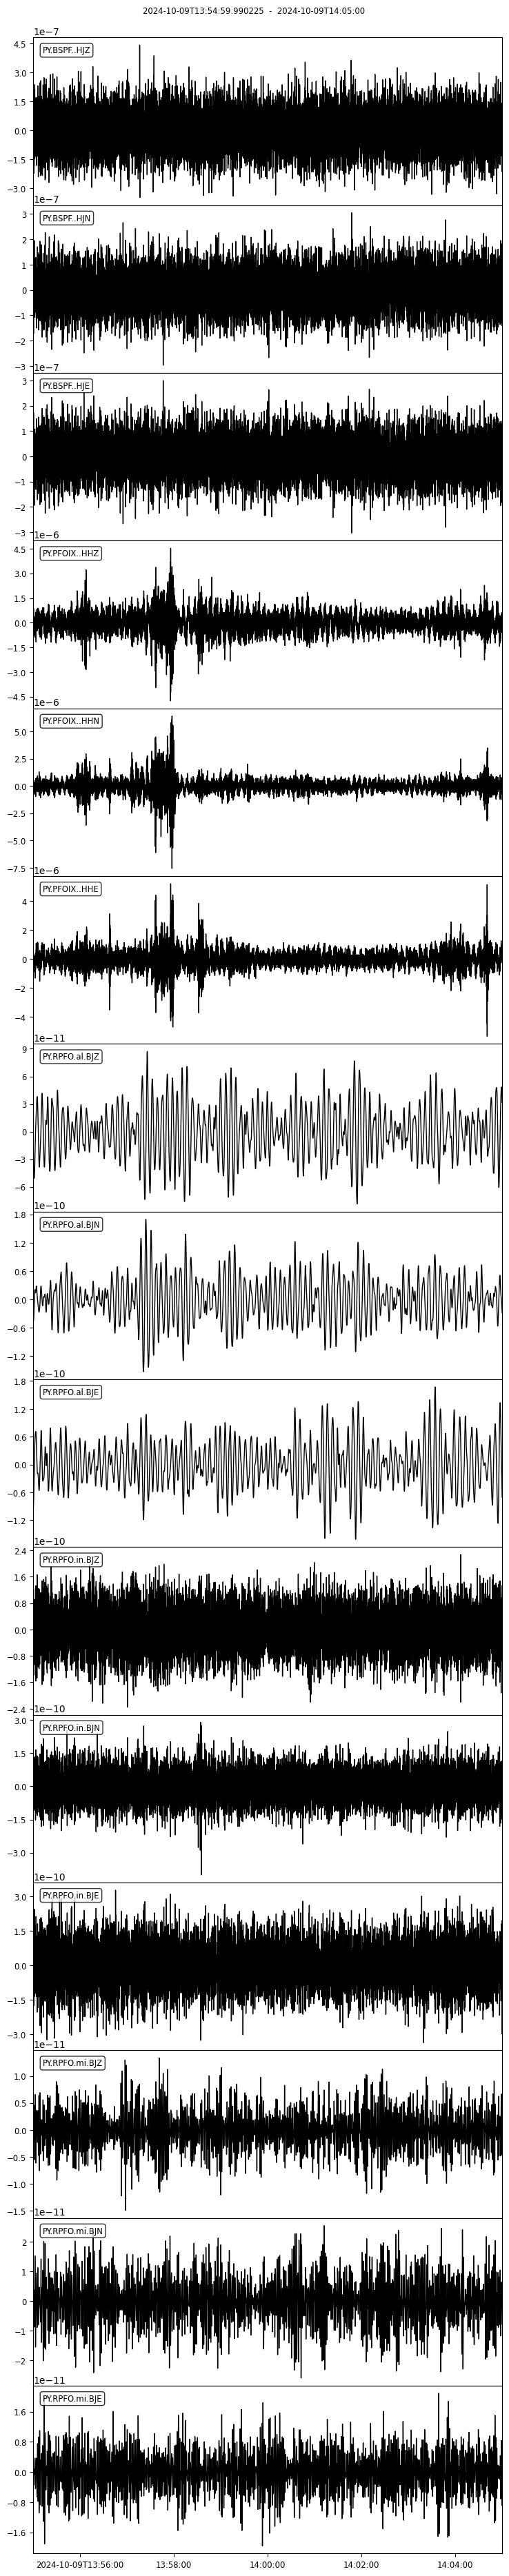

In [31]:
st0 = __get_stream(config['tbeg'], config['tend'])

st0.write(config['path_to_data'], format="MSEED")

st0.plot(equal_scale=False);

### Load Waveforms

In [32]:
st0 = obs.read(config['path_to_data'])

# cut event interval
st0 = st0.trim(st0[0].stats.starttime+config['trim'][0], st0[0].stats.endtime-config['trim'][1])

submask = "mi"

bspf0 = st0.select(station="BSPF").copy()
pfo0 = st0.select(station="PFO*").copy()
adr0 = st0.select(station="RPFO", location=submask[:2]).copy()

if submask == "in":
    config['fmin'], config['fmax'] = 1.0, 5.0
elif submask == "mi":
    config['fmin'], config['fmax'] = 0.5, 1.0
elif submask == "al":
    config['fmin'], config['fmax'] = 0.1, 0.5


## Plot Spectra

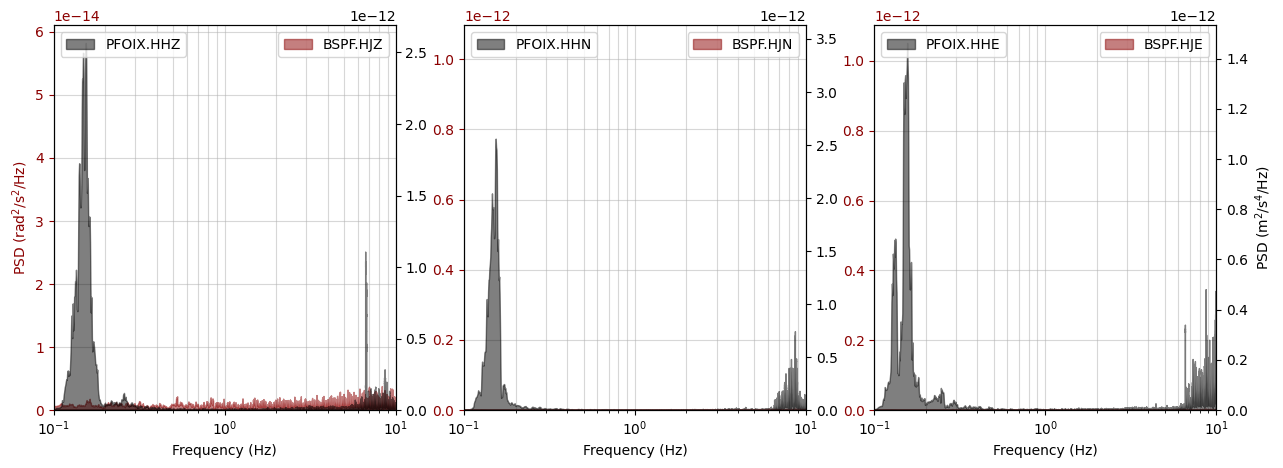

In [33]:
from functions.makeplot_spectra_comparison_fill import __makeplot_spectra_comparison_fill

acc0 = st0.select(station="PFO*").copy()
rot0 = st0.select(station="BSPF").copy()

rot0 = rot0.detrend("simple")
acc0 = acc0.detrend("simple")

fig = __makeplot_spectra_comparison_fill(rot0, acc0, fmin=0.1, fmax=10, ylog=False, xlog=True, fill=True)

# fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_spectra_all.png", format="png", dpi=150, bbox_inches='tight');


In [34]:
from functions.compute_cwt import __compute_cwt

set frequency limit: 15


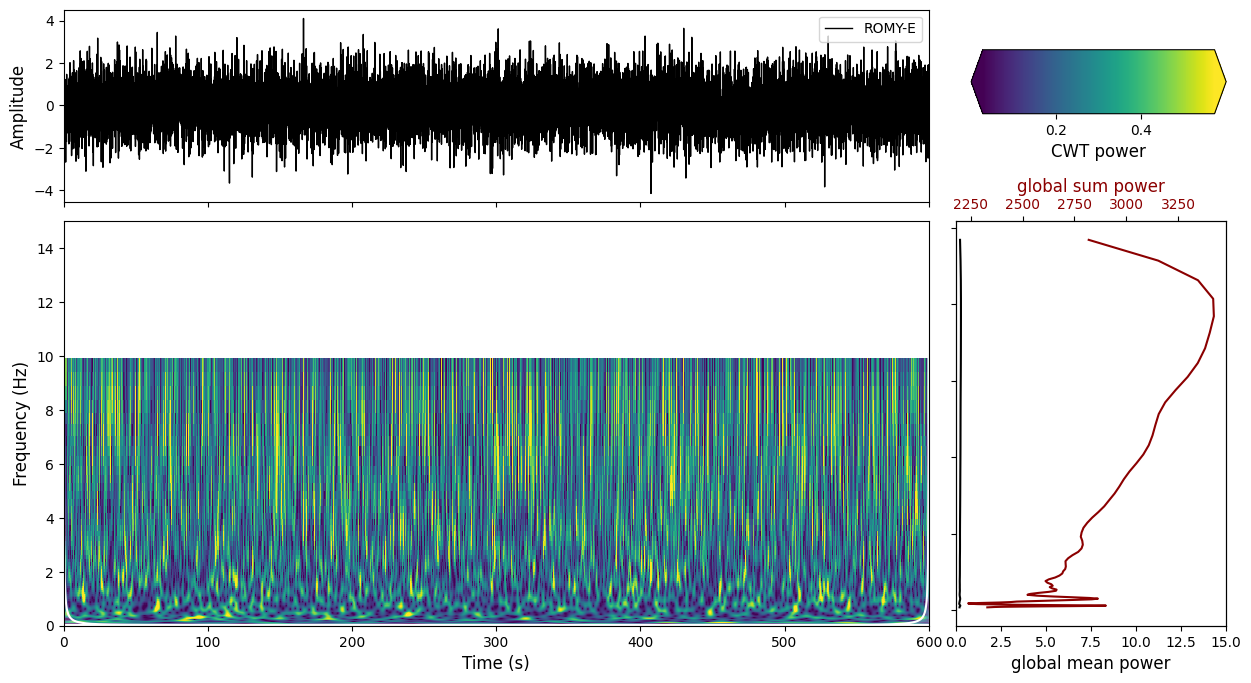

set frequency limit: 15


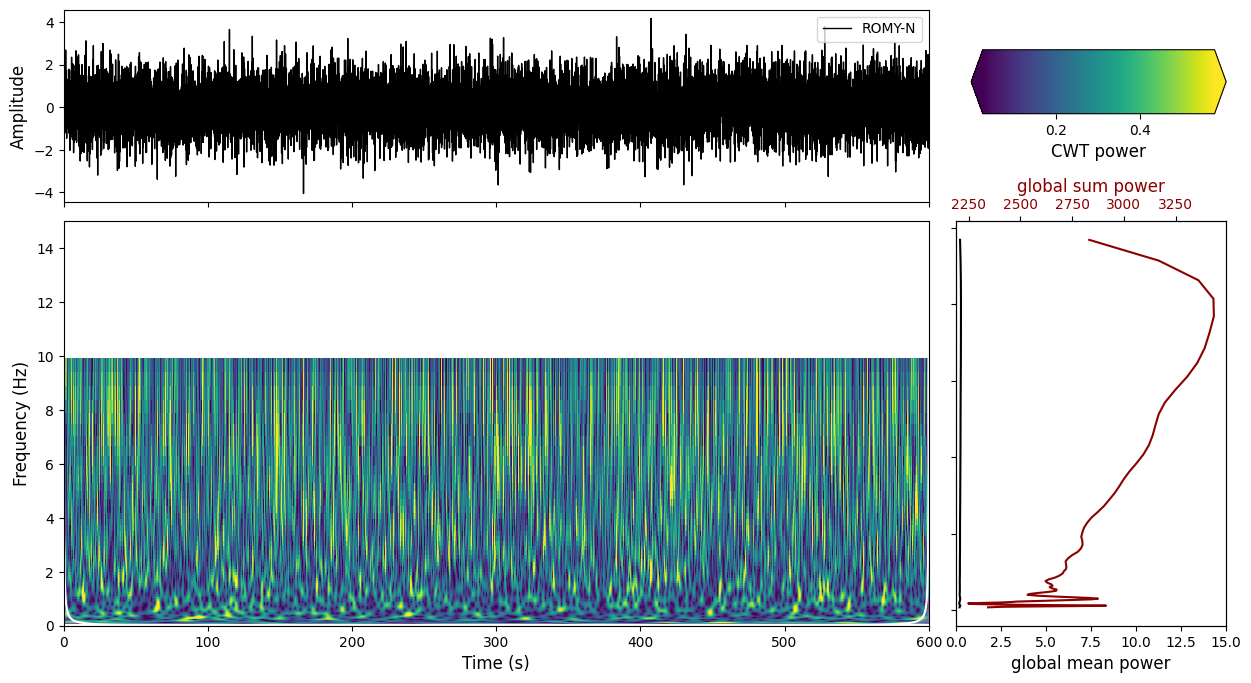

set frequency limit: 15


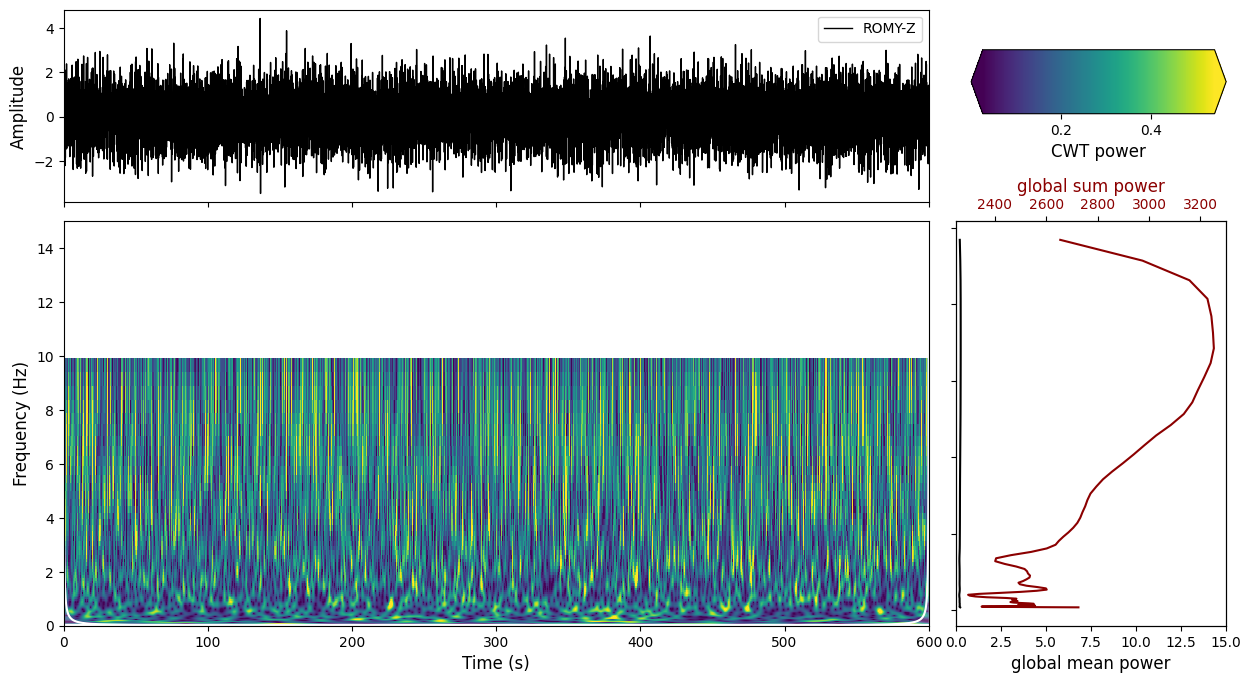

In [35]:
outs = {}
for component in ["E", "N", "Z"]:

    ttt = rot0[0].times()
    arr = rot0.select(channel=f"*{component}")[0].data
    dt = rot0[0].stats.delta # seconds

    out = __compute_cwt(ttt, arr, dt, tscale="sec",
                        datalabel=f"ROMY-{component}",
                        period=False,
                        ymax=15,
                        plot=True,
                       )
    # add to dict
    outs[component] = out

    # # store image
    # out['fig'].savefig(config['path_to_figs']+f"ROMY_{config['name']}_cwt_{component}.png",
    #                    format="png", dpi=150, bbox_inches='tight');


In [36]:
def __makeplot_cwt_all(st0, out, clog=False, ylim=None):

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.gridspec import GridSpec

    def __rmse(arr1, arr2):
        return np.round(np.sqrt(np.mean((arr1-arr2)**2)), 2)

    tscale = 1

    times = st0.select(channel="*N")[0].times()*tscale

    Ncol, Nrow = 1, 9

    font = 12

    cmap = plt.get_cmap("viridis")

    tilt_scale, tilt_unit = 1e6, f"$\mu$rad"

    fig = plt.figure(figsize=(15, 8))

    gs = GridSpec(Nrow, Ncol, figure=fig, hspace=0.1)

    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1:3, :])
    ax3 = fig.add_subplot(gs[3, :])
    ax4 = fig.add_subplot(gs[4:6, :])
    ax5 = fig.add_subplot(gs[6, :])
    ax6 = fig.add_subplot(gs[7:9, :])

    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

    Z = st0.select(channel="*Z")[0].data*tilt_scale
    N = st0.select(channel="*N")[0].data*tilt_scale
    E = st0.select(channel="*E")[0].data*tilt_scale

    periodZ = outs['Z']['frequencies']
    periodN = outs['N']['frequencies']
    periodE = outs['N']['frequencies']

    # _______________________________________________________________
    #
    ax1.plot(times, N, color="k", label="N", lw=1)
    ax1.set_xlim(min(times), max(times))
    ax1.legend(loc=1)
    ax1.set_xticklabels([])

    if clog:
        vmin, vmax, norm = 0.01, 1, "log"
    else:
        vmin, vmax, norm = 0.0, 0.9, None
    # _______________________________________________________________
    #
    im1 = ax2.pcolormesh(out['N']['times']*tscale, periodN, out['N']['cwt_power'],
                         cmap=cmap,
                         vmin=vmin,
                         vmax=vmax,
                         norm=norm,
                        )
    ax2.plot(out['N']['times']*tscale, out['N']['cone'], color="white", ls="--")
    ax2.fill_between(out['N']['times']*tscale, out['N']['cone'], min(periodN)*np.ones(len(out['N']['cone'])), color="white", alpha=0.2)
    ax2.set_xticklabels([])

    if ylim is None:
        ax2.set_ylim(min(periodN), max(periodN))
    else:
        ax2.set_ylim(min(periodN), ylim)

    # _______________________________________________________________
    #
    ax3.plot(times, E, color="k", label="E", lw=1)
    ax3.set_xlim(min(times), max(times))
    ax3.legend(loc=1)
    ax3.set_xticklabels([])

    # _______________________________________________________________
    #
    im2 = ax4.pcolormesh(out['E']['times']*tscale, periodE, out['E']['cwt_power'],
                         cmap=cmap,
                         vmin=vmin,
                         vmax=vmax,
                         norm=norm,
                        )
    ax4.plot(out['E']['times']*tscale, out['E']['cone'], color="white", ls="--")
    ax4.fill_between(out['E']['times']*tscale, out['E']['cone'], min(periodE)*np.ones(len(out['E']['cone'])), color="white", alpha=0.2)
    ax4.set_xticklabels([])

    if ylim is None:
        ax4.set_ylim(min(periodE), max(periodE))
    else:
        ax4.set_ylim(min(periodE), ylim)

    # _______________________________________________________________
    #
    ax5.plot(times, Z, color="k", label="Z", lw=1)
    ax5.set_xlim(min(times), max(times))
    ax5.legend(loc=1)
    ax5.set_xticklabels([])

    # _______________________________________________________________
    #
    im3 = ax6.pcolormesh(out['Z']['times']*tscale, periodE, out['Z']['cwt_power'],
                         cmap=cmap,
                         vmin=vmin,
                         vmax=vmax,
                         norm=norm,
                        )
    ax6.plot(out['Z']['times']*tscale, out['Z']['cone'], color="white", ls="--")
    ax6.fill_between(out['Z']['times']*tscale, out['Z']['cone'], min(periodZ)*np.ones(len(out['Z']['cone'])), color="white", alpha=0.2)

    if ylim is None:
        ax6.set_ylim(min(periodZ), max(periodZ))
    else:
        ax6.set_ylim(min(periodZ), ylim)

    # _______________________________________________________________
    #
    ax1.set_ylabel(f"$\Omega$ ({tilt_unit})", fontsize=font)
    ax2.set_ylabel(f"F (Hz)", fontsize=font)
    ax3.set_ylabel(f"$\Omega$ ({tilt_unit})", fontsize=font)
    ax4.set_ylabel(f"F (Hz)", fontsize=font)
    ax5.set_ylabel(f"$\Omega$ ({tilt_unit})", fontsize=font)
    ax6.set_ylabel(f"F (Hz)", fontsize=font)

    ax6.set_xlabel(f"Time (s) from {config['tbeg'].date} {str(config['tbeg'].time).split('.')[0]} UTC", fontsize=font)


    ax1.text(.005, .97, "(a)", ha='left', va='top', transform=ax1.transAxes, fontsize=font+2)
    ax2.text(.005, .97, "(b)", ha='left', va='top', transform=ax2.transAxes, fontsize=font+2, color="w")
    ax3.text(.005, .97, "(c)", ha='left', va='top', transform=ax3.transAxes, fontsize=font+2)
    ax4.text(.005, .97, "(d)", ha='left', va='top', transform=ax4.transAxes, fontsize=font+2, color="w")
    ax5.text(.005, .97, "(e)", ha='left', va='top', transform=ax5.transAxes, fontsize=font+2)
    ax6.text(.005, .97, "(f)", ha='left', va='top', transform=ax6.transAxes, fontsize=font+2, color="w")

    # add colorbar
    cbar_ax = fig.add_axes([0.92, 0.11, 0.01, 0.77]) #[left, bottom, width, height]
    cb = plt.colorbar(im1, cax=cbar_ax, extend="max")
    cb.set_label("norm. continuous wavelet transform power", fontsize=font, labelpad=-55, color="black")

#     ax1.set_title(f"bandpass = {pmax} - {pmin} hours")

    plt.plot();
    return fig

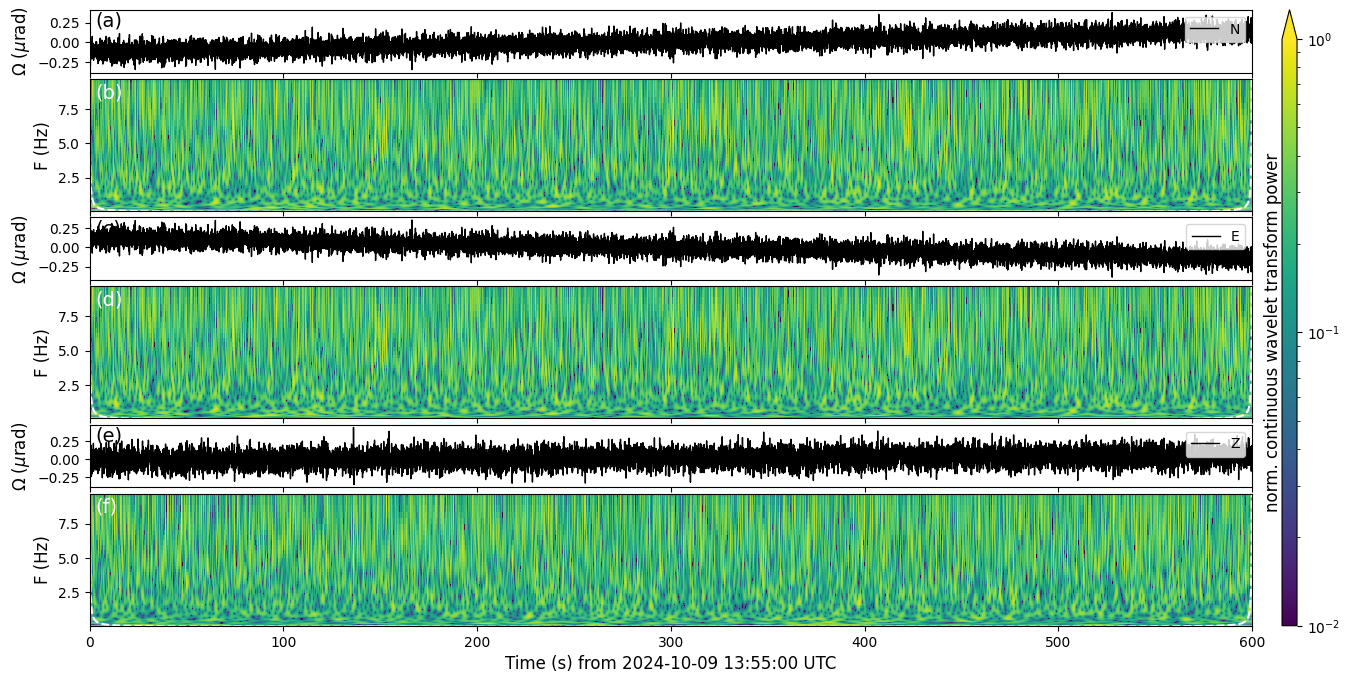

In [37]:
fig = __makeplot_cwt_all(rot0, outs, clog=True, ylim=None)

# fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_cwt_all.png", format="png", dpi=150, bbox_inches='tight');


## Create stream for all data

In [64]:
from functions.makeplot_waveform_comparison_all import __makeplot_waveform_comparison_all

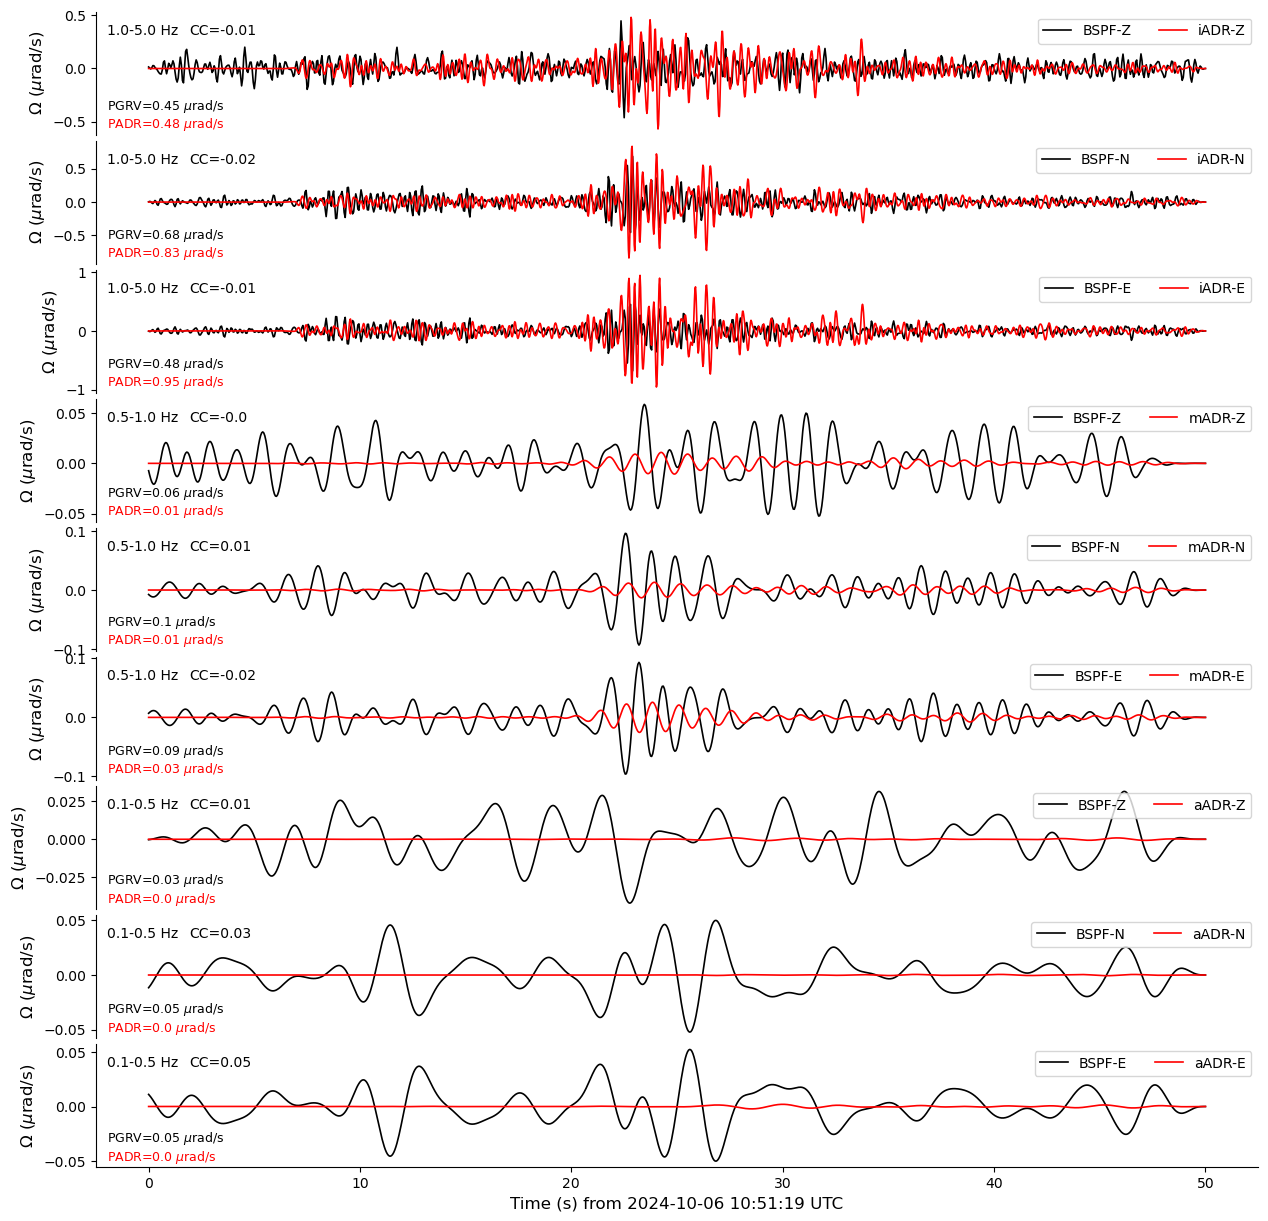

In [65]:
fig = __makeplot_waveform_comparison_all(st0);

# fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_waveforms_all.png", format="png", dpi=150, bbox_inches='tight');


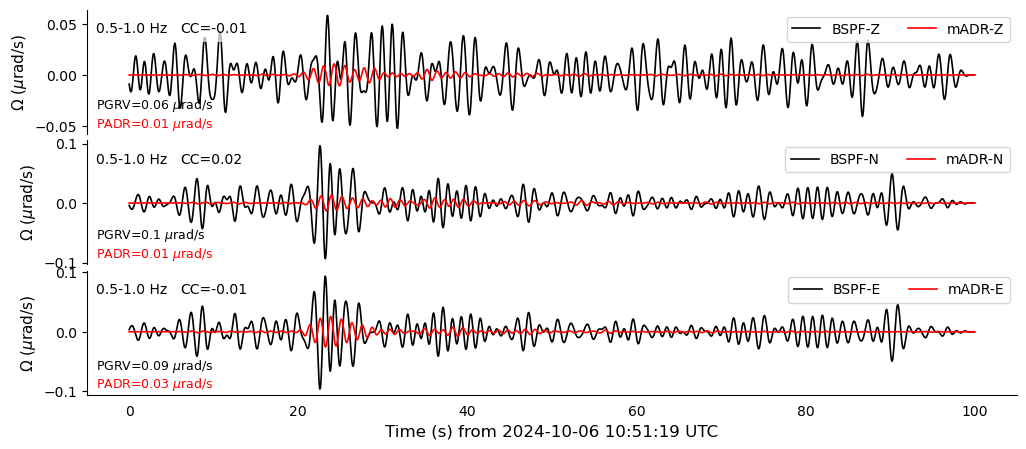

In [53]:
def __makeplot_waveform_comparison(st_in, subarray):

    from obspy.signal.cross_correlation import correlate
    import numpy as np
    import matplotlib.pyplot as plt

    st = st_in.copy()

    # st = st.trim(st[0].stats.starttime+5, st[0].stats.endtime-15).copy()

    fig, ax = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

    lw = 1.2

    font = 12

    fbands = {"in":(1.0, 5.0), "mi":(0.5, 1.0), "al":(0.1, 0.5)}

    offset = [0, 0, 0]

    plt.subplots_adjust(hspace=0.05)

    scaling, unit = 1e6, f"$\mu$rad/s"

    idx = 0
    for _m, array in enumerate([subarray]):

        fband = fbands[array]

        _adr = st.select(location=array).copy()
        _bspf = st.select(station="BSPF").copy()

        _bspf = _bspf.detrend("simple").taper(0.01).filter("bandpass", freqmin=fband[0], freqmax=fband[1], corners=4, zerophase=True)
        _adr = _adr.detrend("simple").taper(0.01).filter("bandpass", freqmin=fband[0], freqmax=fband[1], corners=4, zerophase=True)

        for _k, comp in enumerate(["Z", "N", "E"]):

            ax[idx].plot(_bspf.select(channel=f"*{comp}")[0].times(), _bspf.select(channel=f"*{comp}")[0].data*scaling, label=f"BSPF-{comp}", color="k", lw=lw)
            ax[idx].plot(_adr.select(channel=f"*{comp}")[0].times(), _adr.select(channel=f"*{comp}")[0].data*scaling, label=f"{array[0]}ADR-{comp}", color="r", lw=lw)

            cc = round(correlate(_bspf.select(channel=f"*{comp}")[0].data, _adr.select(channel=f"*{comp}")[0].data, 0, demean=True, normalize='naive', method='auto')[0], 2)

            # rmse = np.round( np.sqrt( np.mean( ( ( _adr.select(channel=f"*{comp}")[0].data - _bspf.select(channel=f"*{comp}")[0].data )*scaling )**2 ) ), 3)

            ## pick peak rotation velocity
            pgrv = round(np.amax(_bspf.select(channel=f"*{comp}")[0].data*scaling), 2)

            ## pick peak adr
            padr = round(np.amax(_adr.select(channel=f"*{comp}")[0].data*scaling), 2)


            t1 = ax[idx].text(0.01, 0.9, f"{fband[0]}-{fband[1]} Hz", ha='left', va='top', transform=ax[idx].transAxes, fontsize=font-2)
            t1.set_bbox(dict(facecolor='white', alpha=0.7, linewidth=0))
            t2 = ax[idx].text(0.1, 0.9, f"CC={cc}", ha='left', va='top', transform=ax[idx].transAxes, fontsize=font-2)
            t2.set_bbox(dict(facecolor='white', alpha=0.7, linewidth=0))
            t3 = ax[idx].text(0.01, 0.30, f"PGRV={pgrv} {unit}", ha='left', va='top', transform=ax[idx].transAxes, fontsize=font-3)
            t3.set_bbox(dict(facecolor='white', alpha=0., linewidth=0))
            t4 = ax[idx].text(0.01, 0.15, f"PADR={padr} {unit}", ha='left', color="r", va='top', transform=ax[idx].transAxes, fontsize=font-3)
            t4.set_bbox(dict(facecolor='white', alpha=0., linewidth=0))

            ax[idx].legend(loc=1, ncols=4, fontsize=font-2)

            # ax[idx].grid(which="both", alpha=0.5)

            ax[idx].set_ylabel(f"$\Omega$ ({unit})", fontsize=font)
            ax[idx].xaxis.label.set_size(font-1)
            ax[idx].yaxis.label.set_size(font-1)

            if idx < 8:
                ax[idx].tick_params(axis='x', bottom=False)

            for pos in ["right", "top", "bottom"]:
                ax[idx].spines[pos].set_visible(False)

            idx += 1

    ax[idx-1].spines["bottom"].set_visible(True)

    ax[idx-1].set_xlabel(f"Time (s) from {st_in[0].stats.starttime.date} {str(st_in[0].stats.starttime.time).split('.')[0]} UTC", fontsize=font)

    # ax[0].set_title(f"{config['tbeg'].date} | {config['fmin']}-{config['fmax']} Hz | ADR {submask} | CC$_Z$ = {cc_Z} | CC$_N$ = {cc_N} | CC$_E$ = {cc_E}")

    plt.show();
    return fig

fig = __makeplot_waveform_comparison(st0, submask);

# fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_waveforms_single.png", format="png", dpi=150, bbox_inches='tight');


## Processing

In [88]:
acc = st0.select(station="PFO*").copy()
rot = st0.select(station="BSPF").copy()

fmin, fmax = 0.5, 1.0
fmin, fmax = 2.0, 8.0

rot = rot.detrend("demean").taper(0.01, type="cosine")
acc = acc.detrend("demean").taper(0.01, type="cosine")

rot = rot.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
acc = acc.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

# for tr in rot:
#     tr.data = np.roll(tr.data, -58*int(rot[0].stats.sampling_rate))

# acc.trim(config['tbeg']+9, config['tend']-5)
# rot.trim(config['tbeg']+9, config['tend']-5)

In [89]:
from functions.makeplot_waveform_comparison_cc import __makeplot_waveform_comparison_cc

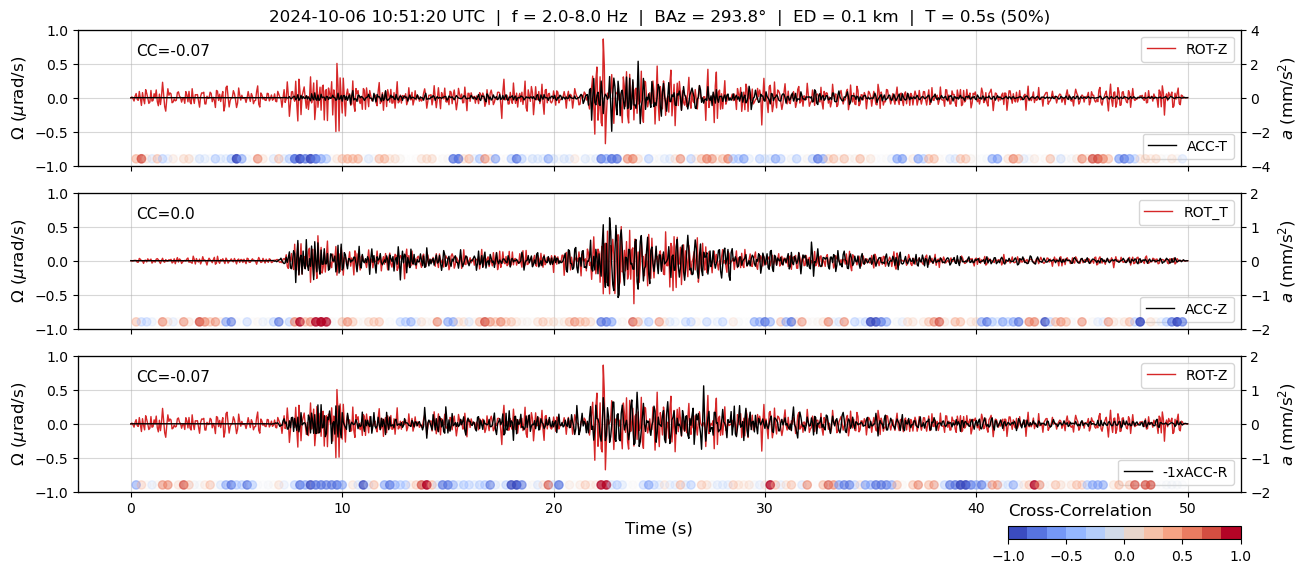

In [90]:
fig = __makeplot_waveform_comparison_cc(rot, acc, baz, fmin, fmax, dist, twin_sec=.5, twin_overlap=0.5)

# fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_waveforms_cc.png", format="png", dpi=150, bbox_inches='tight');


In [ ]:
from functions.cross_correlation_windows import __cross_correlation_windows
from functions.cross_correlation_function_windows import __cross_correlation_function_windows

In [33]:
def __makeplot_comparison_ccf(rot0, acc0, baz, twin_sec=3, twin_overlap=0.5, fmin=None, fmax=None):

    from obspy.signal.cross_correlation import correlate
    from obspy.signal.rotate import rotate_ne_rt
    from numpy import linspace

    def __cross_correlation_function_windows(arr1, arr2, dt, Twin, overlap=0, demean=True):

        from obspy.signal.cross_correlation import correlate, xcorr_max
        from numpy import arange, array, roll, linspace

        N = len(arr1)
        n_interval = int(Twin/dt)
        n_overlap = int(overlap*Twin/dt)

        # time = arange(0, N*dt, dt)

        times, samples = [], []
        n1, n2 = 0, n_interval
        while n2 <= N:
            samples.append((n1, n2))
            times.append(int(n1+(n2-n1)/2)*dt)
            n1 = n1 + n_interval - n_overlap
            n2 = n2 + n_interval - n_overlap

        cc, mm, ss = [], [], []
        for _n, (n1, n2) in enumerate(samples):

            _arr1 = arr1[n1:n2]
            _arr2 = arr2[n1:n2]

            num = len(_arr1)

            ccf = correlate(_arr1, _arr2, num, demean=demean, normalize='naive', method='fft')
            shift, val = xcorr_max(ccf)

            cc.append(ccf)
            mm.append(val)
            ss.append(shift)

        num = int(len(cc[0]))
        tlags = linspace(-num*dt, num*dt, num)

        return array(times), array(cc), tlags, array(ss), array(mm)

    rot = rot0.copy()
    acc = acc0.copy()

    Nrow, Ncol = 3, 1

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 6), sharex=True)

    acc_scaling, acc_unit = 1e3, f"mm/s$^2$"
    rot_scaling, rot_unit = 1e6, f"$\mu$rad/s"

    lw = 1

    font = 12

    acc_z = acc.select(channel="*Z")[0].data
    rot_z = rot.select(channel="*Z")[0].data

    acc_r, acc_t = rotate_ne_rt(acc.select(channel="*N")[0].data, acc.select(channel="*E")[0].data, baz)
    rot_r, rot_t = rotate_ne_rt(rot.select(channel="*N")[0].data, rot.select(channel="*E")[0].data, baz)

    rot_z*=rot_scaling
    rot_r*=rot_scaling
    rot_t*=rot_scaling

    acc_z*=acc_scaling
    acc_r*=acc_scaling
    acc_t*=acc_scaling

    acc_z_max = max([abs(min(acc_z)), abs(max(acc_z))])
    acc_r_max = max([abs(min(acc_r)), abs(max(acc_r))])
    acc_t_max = max([abs(min(acc_t)), abs(max(acc_t))])

    rot_z_max = max([abs(min(rot_z)), abs(max(rot_z))])
    rot_r_max = max([abs(min(rot_r)), abs(max(rot_r))])
    rot_t_max = max([abs(min(rot_t)), abs(max(rot_t))])

    dt = rot[0].stats.delta


    cmap = plt.get_cmap("coolwarm", 12)

    ttt0, ccf0, tlags0, shifts0, maxima0 = __cross_correlation_function_windows(-acc_t, rot_z, dt, twin_sec, overlap=twin_overlap, demean=True)
    ttt1, ccf1, tlags1, shifts1, maxima1 = __cross_correlation_function_windows(acc_z, rot_t, dt, twin_sec, overlap=twin_overlap, demean=True)
    ttt2, ccf2, tlags2, shifts2, maxima2 = __cross_correlation_function_windows(acc_r, rot_z, dt, twin_sec, overlap=twin_overlap, demean=True)


    cm0 = ax[0].pcolormesh(ttt0, tlags0, ccf0.T, rasterized=True, vmin=-1, vmax=1, cmap=cmap)
    ax[0].set_ylim(min(tlags0), max(tlags0))
    ax[0].set_xlim(min(ttt0), max(ttt0))
    ax[0].scatter(ttt0, shifts0*dt, s=2, color="k", alpha=0., zorder=4, label="-1x ACC-T & ROT-Z")

    ax[1].pcolormesh(ttt1, tlags1, ccf1.T, rasterized=True, vmin=-1, vmax=1, cmap=cmap)
    ax[1].set_ylim(min(tlags1), max(tlags1))
    ax[1].set_xlim(min(ttt1), max(ttt1))
    ax[1].scatter(ttt1, shifts1*dt, s=2, color="k", alpha=0., zorder=4, label="ACC-Z & ROT-T")

    ax[2].pcolormesh(ttt2, tlags2, ccf2.T, rasterized=True, vmin=-1, vmax=1, cmap=cmap)
    ax[2].set_ylim(min(tlags2), max(tlags2))
    ax[2].set_xlim(min(ttt2), max(ttt2))
    ax[2].scatter(ttt2, shifts2*dt, s=2, color="k", alpha=0., zorder=4, label="ACC-R & ROT-Z")


    for i in range(3):
        ax[i].legend(loc=2, ncols=4)
        ax[i].grid(which="both", alpha=0.5)
        ax[i].set_ylabel(f"Lagtime (s)", fontsize=font)

    ax[2].set_xlabel("Time (s)", fontsize=font)

    tbeg = acc[0].stats.starttime
    ax[0].set_title(f"{tbeg.date} {str(tbeg.time).split('.')[0]} UTC  |  f = {fmin}-{fmax} Hz  |  BAz = {round(baz, 1)}°  |  ED = {round(dist/1000,1)} km  |  T = {twin_sec}s ({int(100*twin_overlap)}%)")

    ## add colorbar
    cax = ax[Nrow-1].inset_axes([0.8, -0.3, 0.2, 0.1], transform=ax[Nrow-1].transAxes)
    cb = plt.colorbar(cm0, cax=cax, shrink=0.4, location='bottom', orientation='horizontal')
    cm0.set_clim(-1, 1)
    cb.set_label("CC-Coeff.", labelpad=-40)

    plt.show();
    return fig

# fig = __makeplot_comparison_ccf(rot, acc, baz, twin_sec=0.2, twin_overlap=0.5, fmin=fmin, fmax=fmax)


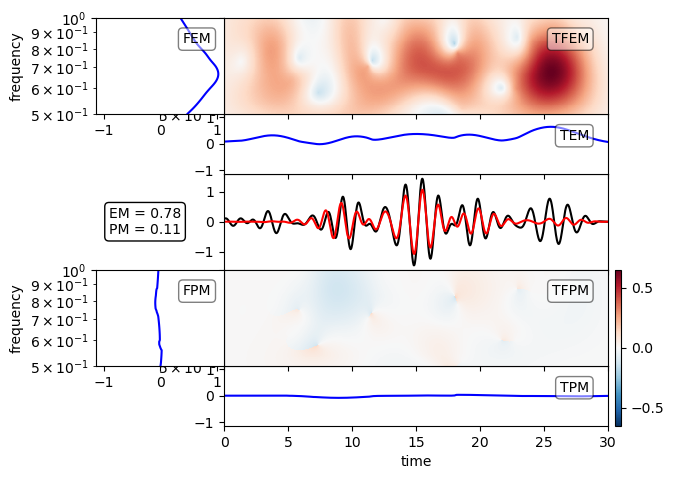

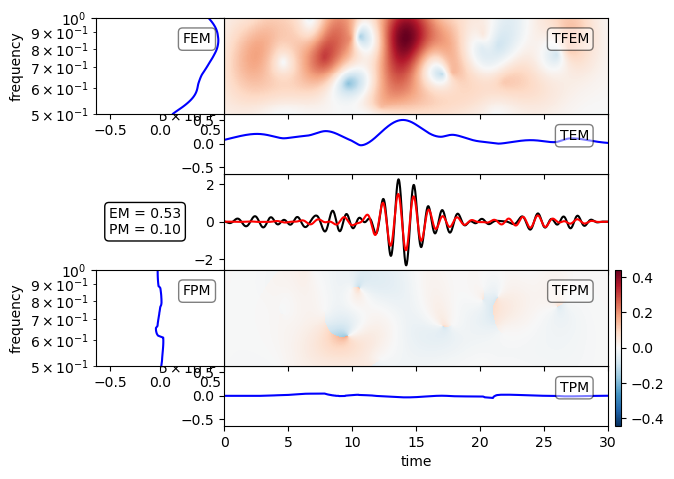

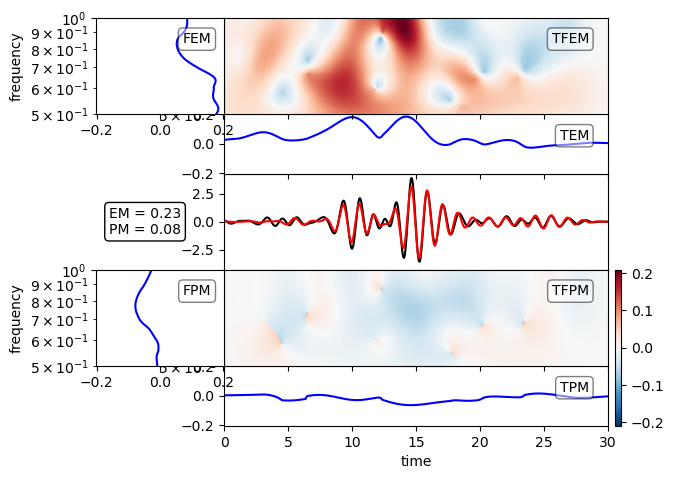

In [40]:
from scipy.signal import hilbert
from obspy.signal.tf_misfit import plot_tf_misfits

array = "mi"

for component in ["Z", "N", "E"]:


    st1 = st0.copy()

    st1 = st1.detrend("demean").taper(0.01, type="cosine").filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

    s1 = st1.select(station="BSPF", channel=f"*{component}")[0].data
    s2 = st1.select(station="RPFO", location=array, channel=f"*{component}")[0].data

    plot_tf_misfits(s1, s2, dt=st1[0].stats.delta, fmin=fmin, fmax=fmax, show=True, norm="global")


## Backazimuth Estimate

In [41]:
from functions.compute_backazimuth import __compute_backazimuth
from functions.get_theoretical_backazimuth import __get_theoretical_backazimuth
from functions.compute_backazimuth_tangent import __compute_backazimuth_tangent
from functions.compare_backazimuth_codes import __compare_backazimuth_codes

In [49]:
config['station_longitude'] = config['sta_lon']
config['station_latitude']  = config['sta_lat']

## specify window length for baz estimation in seconds
config['win_length_sec'] = 2/fmin

## define an overlap for the windows in percent (50 -> 50%)
config['overlap'] = 90

## specify steps for degrees of baz
config['step'] = 1


baz, az, dist = __get_theoretical_backazimuth(config['sta_lat'], config['sta_lon'], event_obj=config['event'], fdsn_client='USGS')

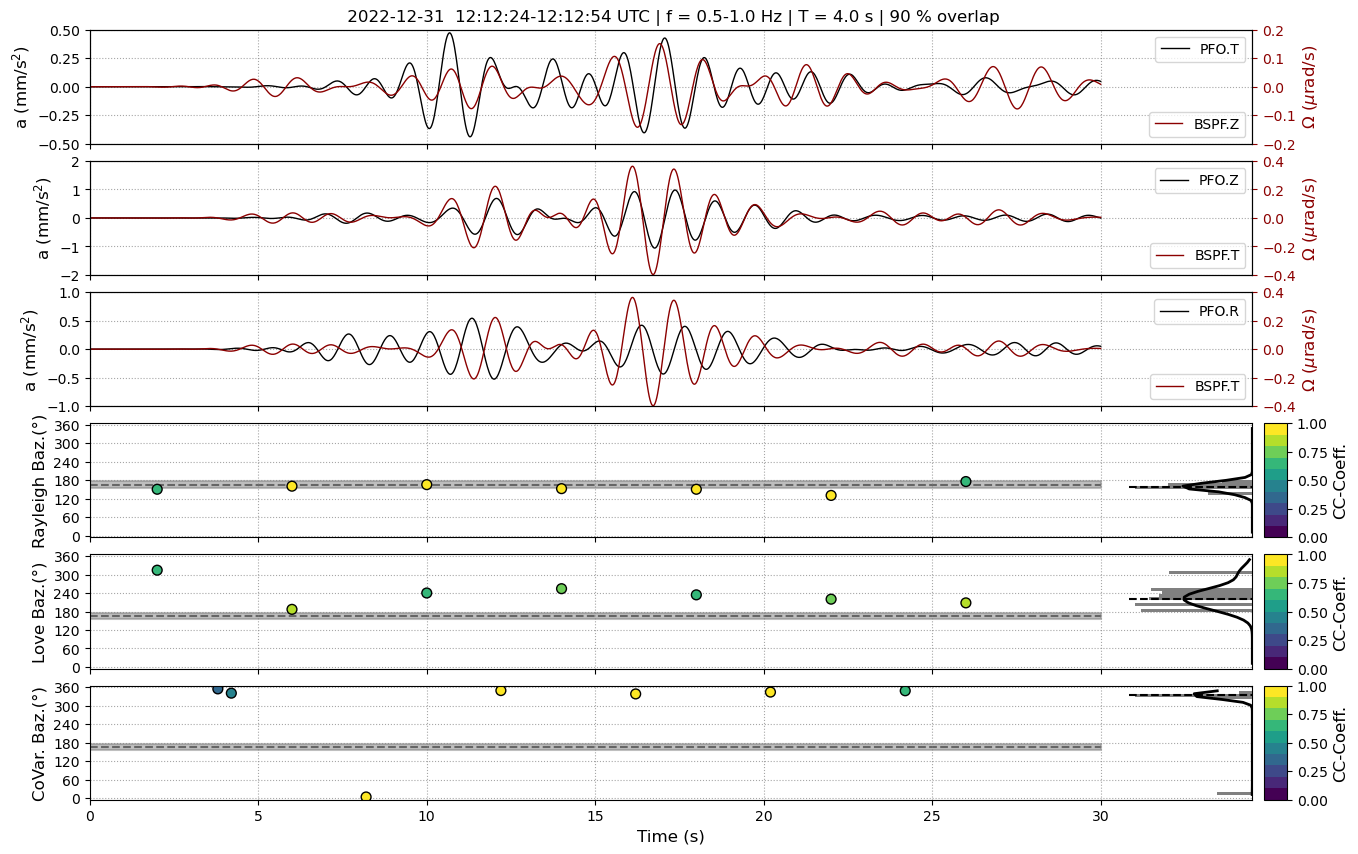

In [50]:
out4 = __compare_backazimuth_codes(rot, acc,
                                   config['event'],
                                   fmin, fmax,
                                   config['win_length_sec'],
                                   config['overlap'],
                                   cc_thres=0.,
                                   invert_rot_z=False,
                                   invert_acc_z=True,
                                   plot=True,
                                  );

out4['fig3'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_{rot[0].stats.location}_{fmin}_{fmax}_all.png", dpi=150, bbox_inches='tight', pad_inches=0.05);


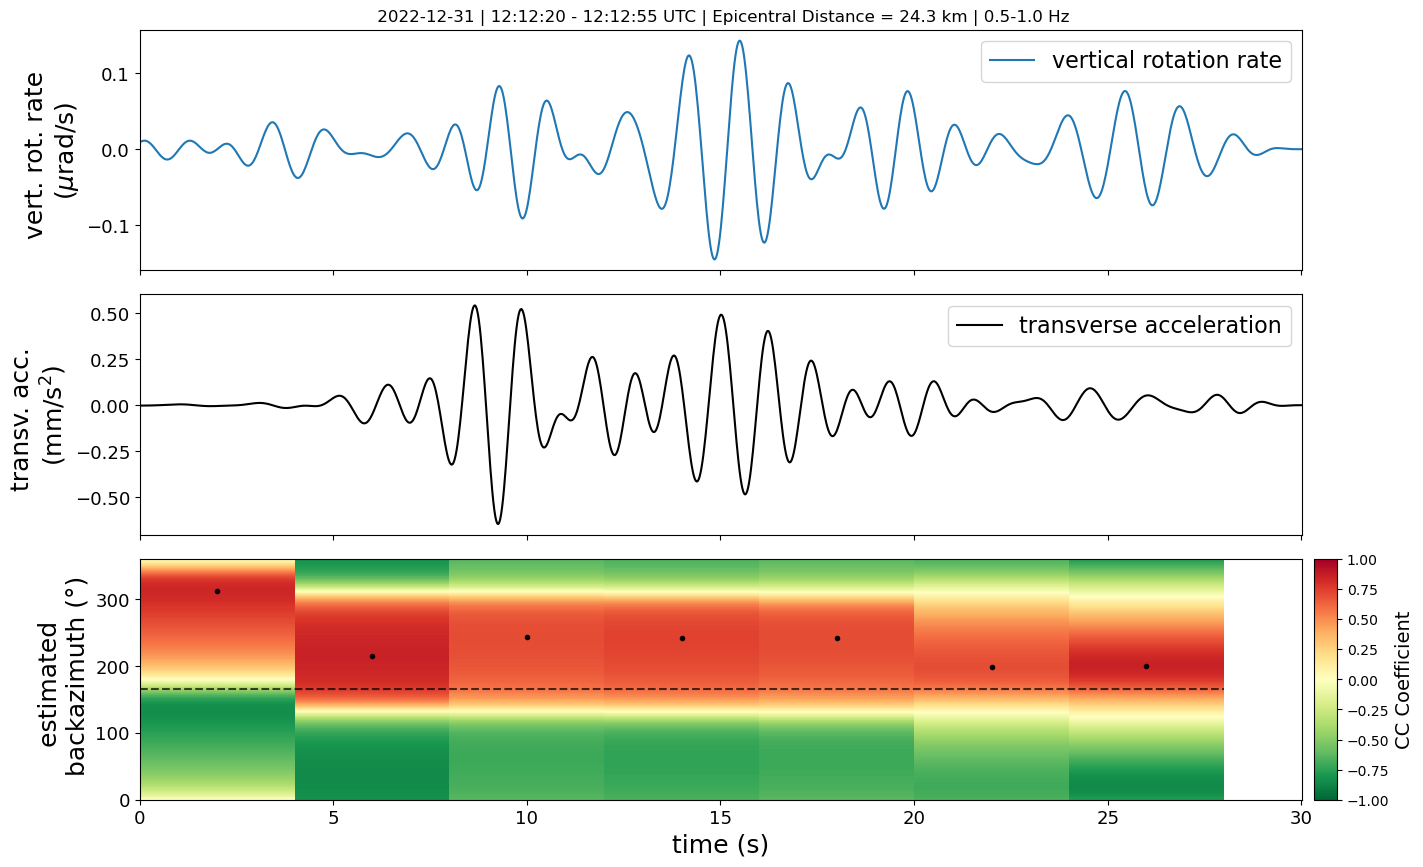

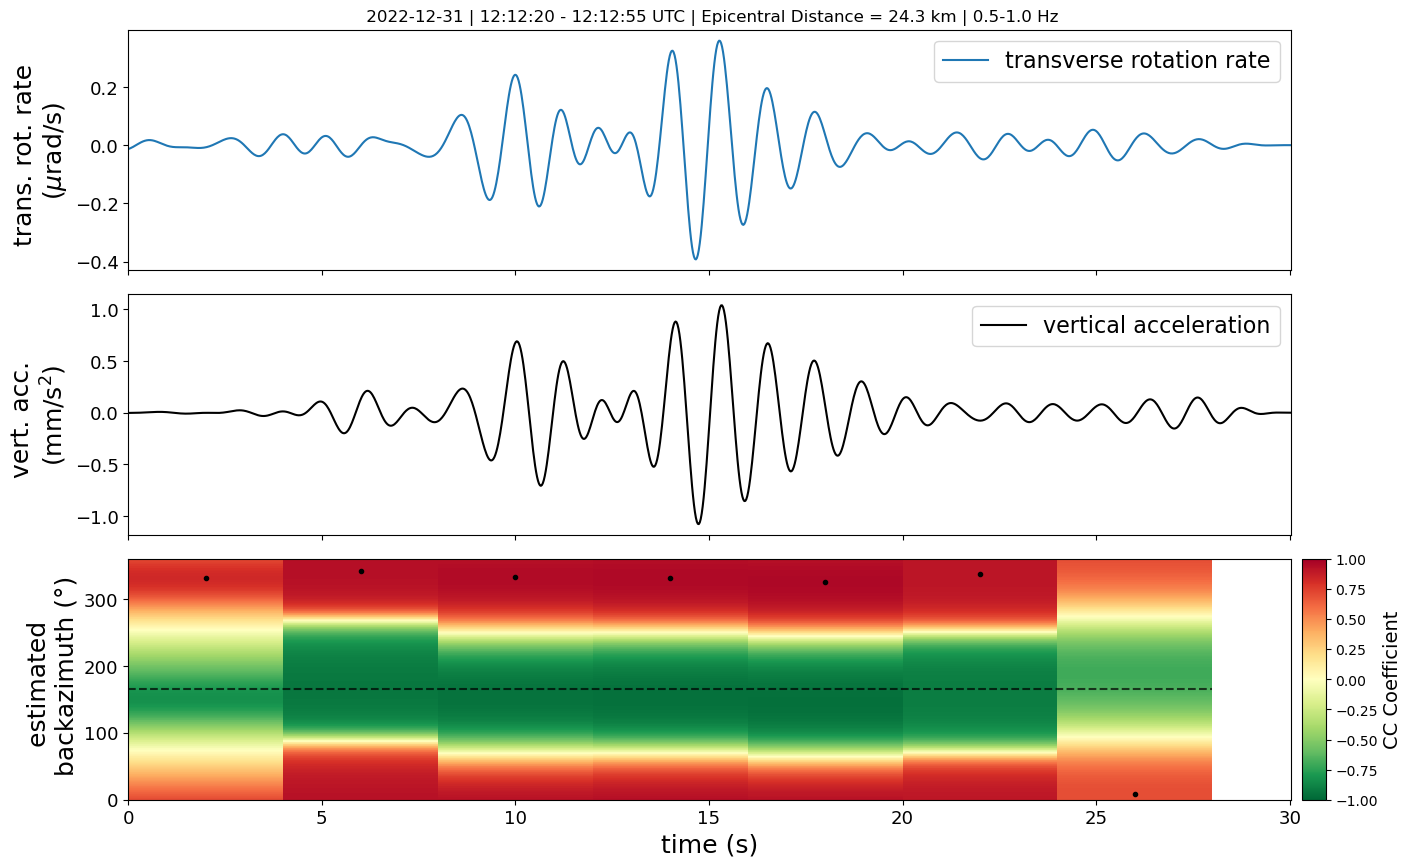

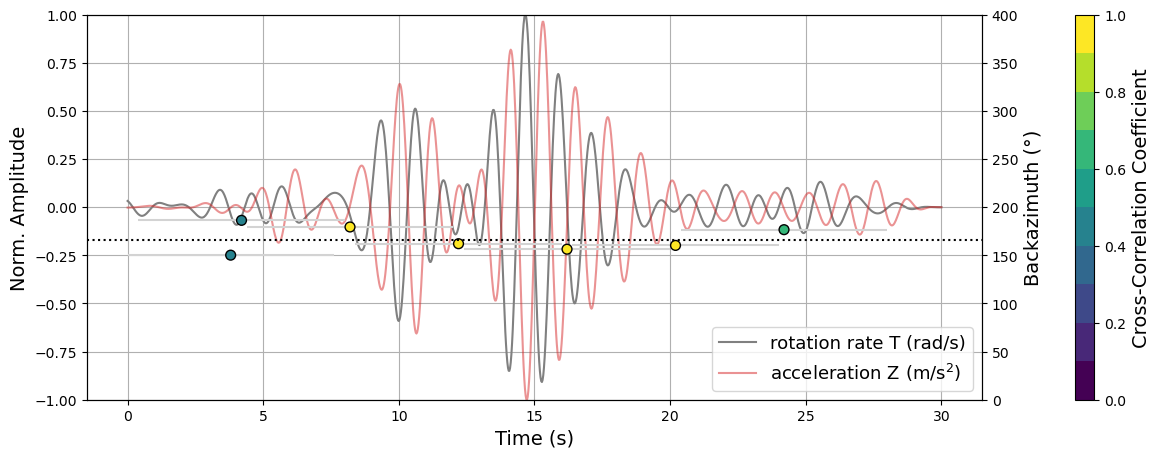

In [51]:
out1 = __compute_backazimuth(
                            acc,
                            rot,
                            config,
                            wave_type='love',
                            event=config['event'],
                            plot=True,
                            flim=(fmin, fmax),
                            invert_rot_z=False,
                            show_details=False,
)

out1['fig'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_love_{fmin}_{fmax}.png", dpi=150, bbox_inches='tight', pad_inches=0.05)


out2 = __compute_backazimuth(
                            acc,
                            rot,
                            config,
                            wave_type='rayleigh',
                            event=config['event'],
                            plot=True,
                            flim=(fmin, fmax),
                            show_details=False,
)

out2['fig'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_rayleigh_{fmin}_{fmax}.png", dpi=150, bbox_inches='tight', pad_inches=0.05)


out3 = __compute_backazimuth_tangent(
                                    rot,
                                    acc,
                                    win_time_s=config['win_length_sec'],
                                    overlap=config['overlap']/100,
                                    baz_theo=baz,
                                    cc_thres=0.1,
                                    plot=True,
                                    invert_acc_z=False,
                                    )

out3['fig'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_tangent_{rot[0].stats.station}{fmin}_{fmax}.png", dpi=150, bbox_inches='tight', pad_inches=0.05)


## Compare backazimuth estimate for ADR, BSPF and Beamforming

In [45]:
from functions.compute_beamforming_pfo import __compute_beamforming_pfo

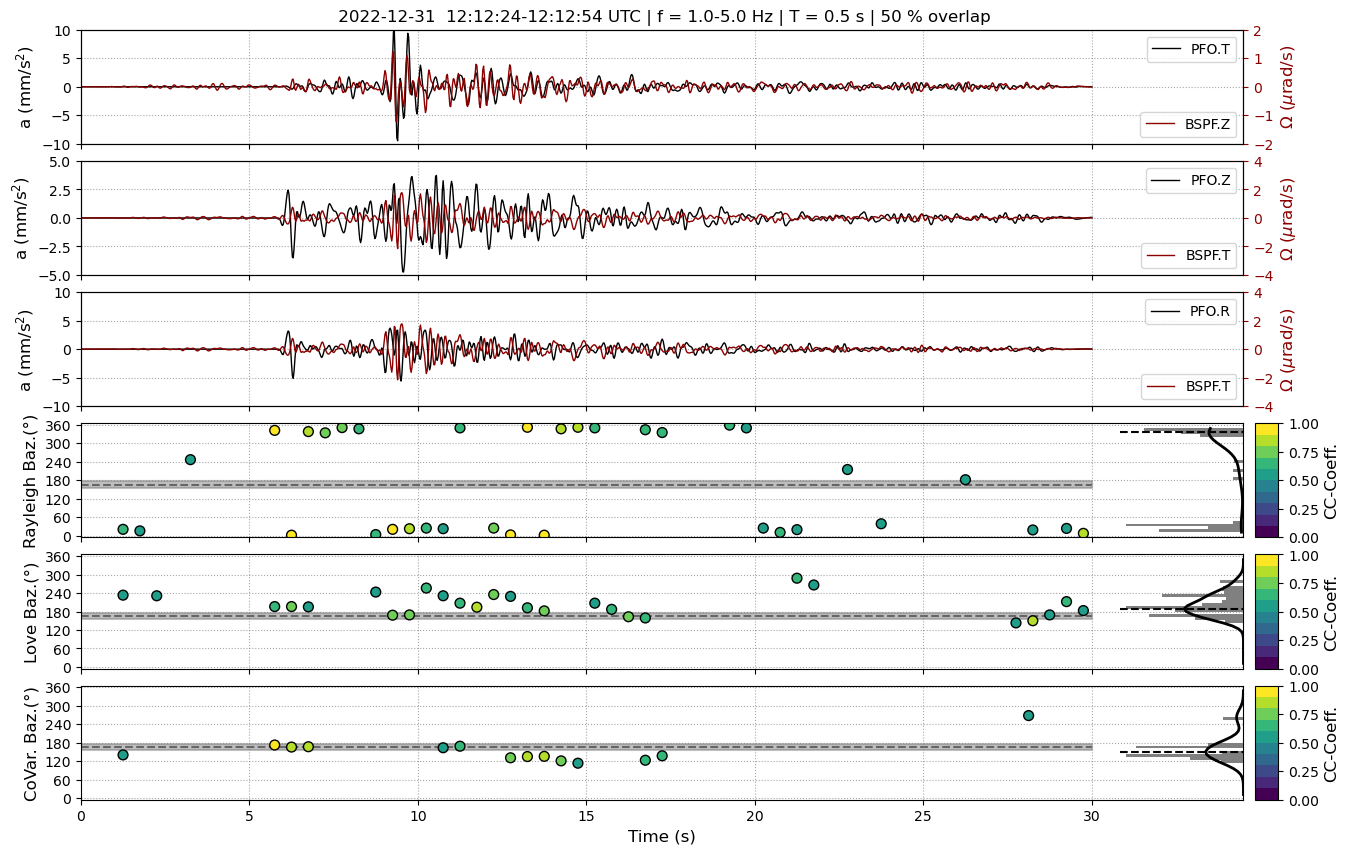

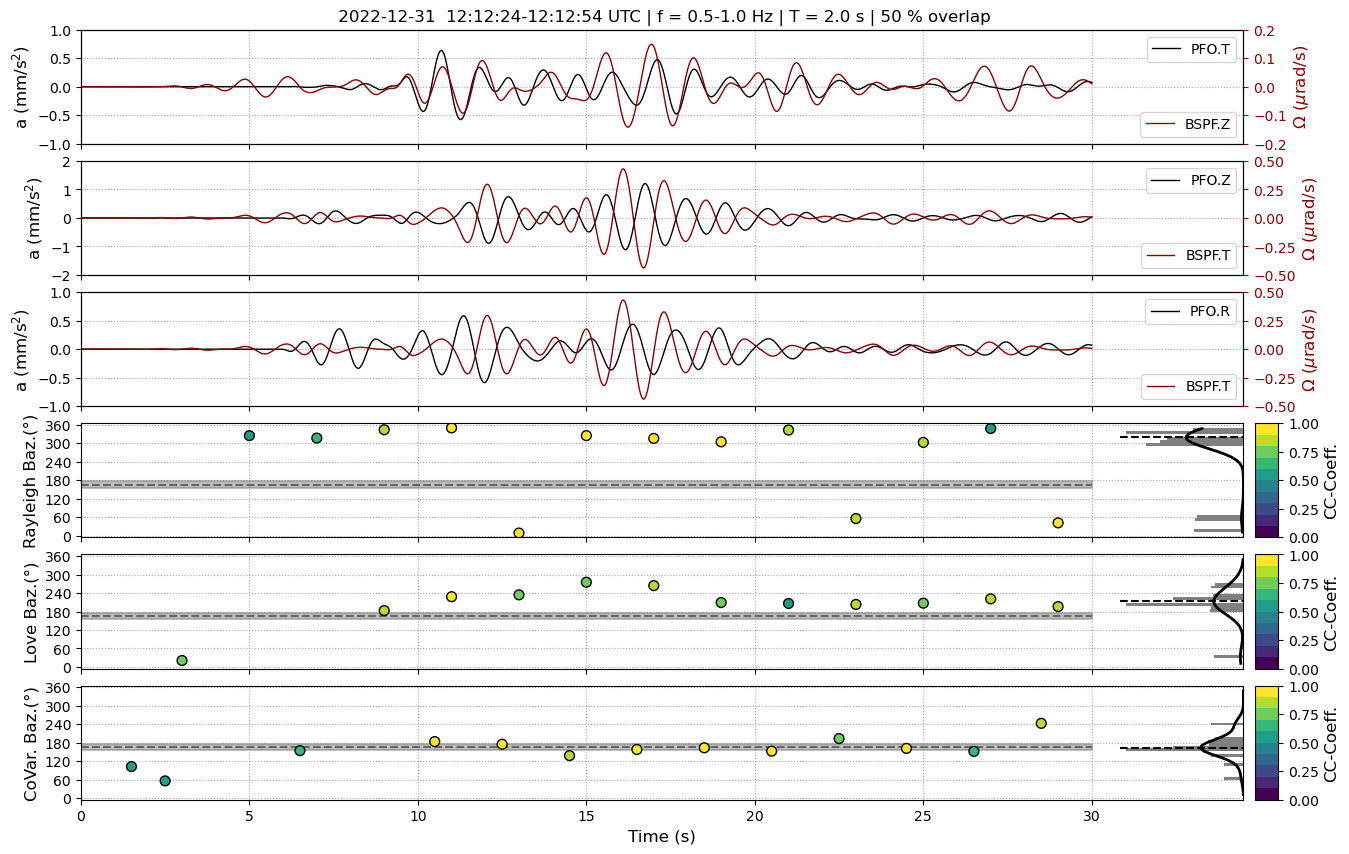

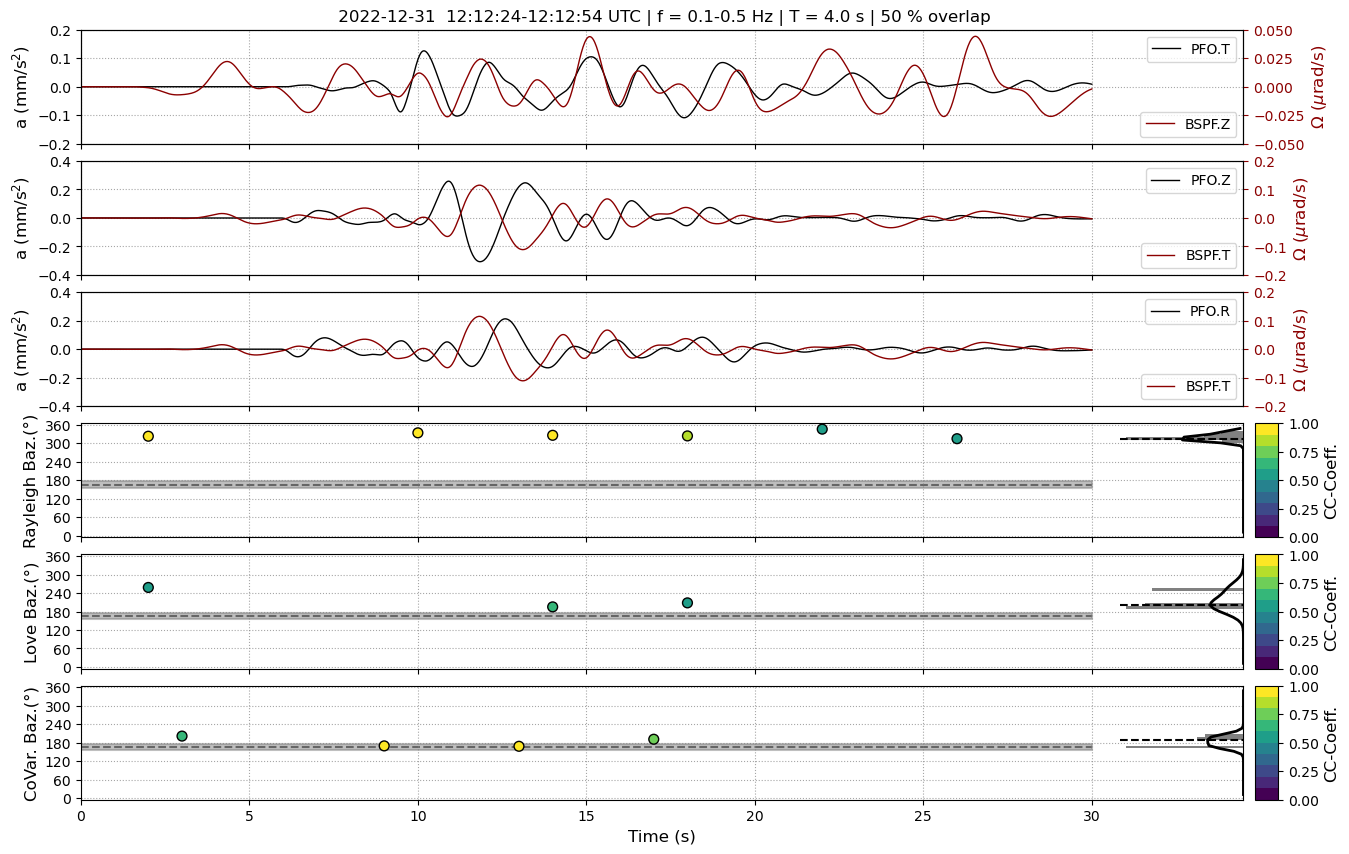

 -> obtained: 5 of 5 stations!

 -> Runtime: 0.48 minutes
 -> obtained: 8 of 8 stations!

 -> Runtime: 0.8 minutes
 -> obtained: 13 of 13 stations!

 -> Runtime: 1.3 minutes


In [46]:
stt = st0.copy();

acc0 = stt.copy().select(station="PFO*");
rot0 = stt.copy().select(station="BSPF");

for tr in acc0:
    if "Z" in tr.stats.channel:
        tr.data *= -1

cc_thres = 0.5

Twin_factor = 1
Twin_overlap = 50

## direct rotation
out_bspf_i = __compare_backazimuth_codes(rot0, acc0, config['event'], 1.0, 5.0, Twin_factor/2.0, Twin_overlap,
                                         cc_thres=cc_thres, invert_acc_z=True, plot=True);
out_bspf_i['fig3'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_{rot[0].stats.location}_2.0_5.0_all.png",
                           dpi=200, bbox_inches='tight', pad_inches=0.05);

out_bspf_m = __compare_backazimuth_codes(rot0, acc0, config['event'], 0.5, 1.0, Twin_factor/0.5, Twin_overlap,
                                         cc_thres=cc_thres, invert_acc_z=True, plot=True);
out_bspf_m['fig3'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_{rot[0].stats.location}_0.5_1.0_all.png",
                           dpi=200, bbox_inches='tight', pad_inches=0.05);

out_bspf_a = __compare_backazimuth_codes(rot0, acc0, config['event'], 0.1, 0.5, Twin_factor/0.25, Twin_overlap,
                                         cc_thres=cc_thres, invert_acc_z=True, plot=True);
out_bspf_a['fig3'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_{rot[0].stats.location}_0.1_0.5_all.png",
                           dpi=200, bbox_inches='tight', pad_inches=0.05);


## adr rotation
rot1 = stt.copy().select(station="RPFO", location="in");
out_adr_i = __compare_backazimuth_codes(rot1, acc0, config['event'], 1.0, 5.0, Twin_factor/2.0, Twin_overlap,
                                        cc_thres=cc_thres, invert_acc_z=True, plot=False);

rot2 = stt.copy().select(station="RPFO", location="mi");
out_adr_m = __compare_backazimuth_codes(rot2, acc0, config['event'], 0.5, 1.0, Twin_factor/0.5, Twin_overlap,
                                        cc_thres=cc_thres, invert_acc_z=True, plot=False);

rot3 = stt.copy().select(station="RPFO", location="al");
out_adr_a = __compare_backazimuth_codes(rot3, acc0, config['event'], 0.1, 0.5, Twin_factor/0.25, Twin_overlap,
                                        cc_thres=cc_thres, invert_acc_z=True, plot=False);

## array beamforming
out_bf_i = __compute_beamforming_pfo(config['tbeg'], config['tend'], fmin=1.0, fmax=5.0, component="Z", submask="inner", plot=False)
out_bf_m = __compute_beamforming_pfo(config['tbeg'], config['tend'], fmin=0.5, fmax=1.0, component="Z", submask="mid", plot=False)
out_bf_a = __compute_beamforming_pfo(config['tbeg'], config['tend'], fmin=0.1, fmax=0.5, component="Z", submask="all", plot=False)
# out_bf_o = __compute_beamforming_pfo(config['tbeg'], config['tend'], fmin=0.8, fmax=1.0, component="Z", submask="mid", plot=False)


In [47]:
def __makeplot_comparison():

    labels = ["iBSPF", "iADR", "iBF", "mBSPF", "mADR", "mBF", "aBSPF", "aADR", "aBF"]

    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    font = 16

    ax.axhline(out_bspf_i['baz_theo'], color="k", ls="--", label="theo. Baz.")
    ax.fill_between([-0.3, 4.0], out_bspf_i['baz_theo']-10, out_bspf_i['baz_theo']+10, color="grey", alpha=0.5, label="theo. Baz. +- 10°")


    for j, out in enumerate([out_adr_i, out_adr_m, out_adr_a]):

        ax.errorbar(j-0.02, out['baz_tangent_max'], yerr=out['baz_tangent_std'], color="tab:blue", zorder=2)
        ax.errorbar(j, out['baz_love_max'], yerr=out['baz_love_std'], color="tab:green", zorder=2)
        ax.errorbar(j+0.02, out['baz_rayleigh_max'], yerr=out['baz_rayleigh_std'], color="tab:red", zorder=2)

        ax.scatter(j-0.02, out['baz_tangent_max'], color="tab:blue", zorder=2, label="Co.Var.", edgecolors="k")
        ax.scatter(j, out['baz_love_max'], color="tab:green", zorder=2, label="Love", edgecolors="k")
        ax.scatter(j+0.02, out['baz_rayleigh_max'], color="tab:red", zorder=2, label="Rayleigh", edgecolors="k")

        ## plot only for legend icon

        if j == 0:
            ax.scatter(j+0.4, out_bf_i['baz_bf_max'], color="tab:orange", zorder=2, label="beamforming", edgecolors="k")
            ax.legend(loc=1, fontsize=font-3)


    for j, out in enumerate([out_bspf_i, out_bspf_m, out_bspf_a]):

        ax.errorbar(j+0.18, out['baz_tangent_max'], yerr=out['baz_tangent_std'], color="tab:blue", zorder=2)
        ax.errorbar(j+0.2, out['baz_love_max'], yerr=out['baz_love_std'], color="tab:green", zorder=2)
        ax.errorbar(j+0.22, out['baz_rayleigh_max'], yerr=out['baz_rayleigh_std'], color="tab:red", zorder=2)

        ax.scatter(j+0.18, out['baz_tangent_max'], color="tab:blue", zorder=2, label="Co.Var.", edgecolors="k")
        ax.scatter(j+0.2, out['baz_love_max'], color="tab:green", zorder=2, label="Love", edgecolors="k")
        ax.scatter(j+0.22, out['baz_rayleigh_max'], color="tab:red", zorder=2, label="Rayleigh", edgecolors="k")


    for j, out in enumerate([out_bf_i, out_bf_m, out_bf_a]):

        ax.errorbar(j+0.4, out['baz_bf_max'], yerr=out['baz_bf_std'], color="tab:orange", zorder=2)
        ax.scatter(j+0.4, out['baz_bf_max'], color="tab:orange", zorder=2, label="", edgecolors="k")



    ax.set_xticks([0,0.2,0.4,1,1.2,1.4,2,2.2,2.4], labels=labels, fontsize=font-1)

    ax.grid(axis="y", ls=":", color="k", alpha=0.5, zorder=0)

    ax.text(0, 360+10, "1.0 - 5.0 Hz", fontsize=font-1)
    ax.text(1, 360+10, "0.5 - 1.0 Hz", fontsize=font-1)
    ax.text(2, 360+10, "0.1 - 0.5 Hz", fontsize=font-1)
    # ax.text(3, 360+10, "0.8 - 1.0 Hz", fontsize=font-1)

    ax.xaxis.label.set_size(font-1)
    ax.yaxis.label.set_size(font-1)

    ax.set_ylim(-5, 365)
    ax.set_yticks(range(0, 360+60,60))

    ax.set_ylabel("Backazimuth (°)", fontsize=font)

    ax.set_xlim(-0.3, 3.0)
    ax.set_ylim(0, 360)

    plt.show();
    return fig

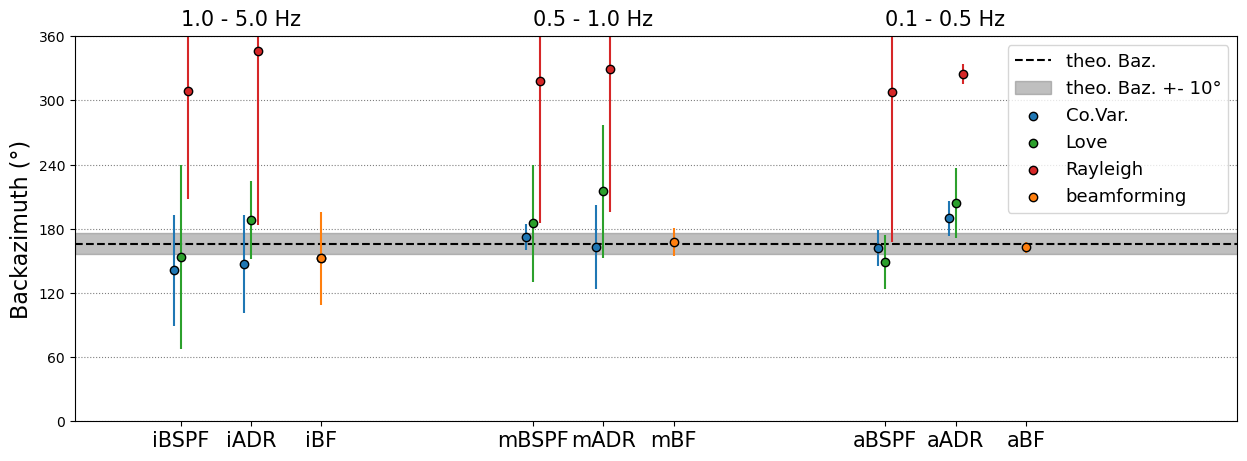

In [48]:
fig = __makeplot_comparison()

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_overview.png", dpi=200, bbox_inches='tight', pad_inches=0.05);


## Phase Velocity

In [ ]:
from functions.compute_velocity_from_amplitude_ratio import __compute_velocity_from_amplitude_ratio

In [ ]:
from functions.makeplot_velocities import __makeplotStream_velocities

In [ ]:
acc = st0.select(station="PFO*").copy();
rot = st0.select(station="BSPF").copy();
# rot = st0.select(station="RPFO", location="mi").copy()

fmin, fmax = 0.5, 1.0

rot.detrend("demean").taper(0.1).filter("bandpass", freqmin=fmin, freqmax=fmax, zerophase=True, corners=4);
acc.detrend("demean").taper(0.1).filter("bandpass", freqmin=fmin, freqmax=fmax, zerophase=True, corners=4);


In [ ]:
fig = __makeplotStream_velocities(rot, acc, fmin, fmax, baz,
                                  overlap=0.75, cc_threshold=0.8,
                                  reverse_rotZ=False, reverse_accZ=True,
                                 );

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_velocities_{rot[0].stats.station}_{fmin}_{fmax}.png", dpi=200, bbox_inches='tight', pad_inches=0.05)


### Velocity in F-Bands

In [ ]:
from functions.estimate_velocity_in_fbands import __estimate_velocity_in_fbands

In [ ]:
st = st0.copy()

fig1, fig2 = __estimate_velocity_in_fbands(rot0, acc0, baz)


fig1.savefig(config['path_to_figs']+f"BSFP_{config['name']}_Love_velocity_fbands_{rot[0].stats.station}.png", format="png", dpi=150, bbox_inches='tight')

fig2.savefig(config['path_to_figs']+f"BSFP_{config['name']}_Rayleigh_velocity_fbands_{rot[0].stats.station}_{rot[0].stats.location}.png", format="png", dpi=200, bbox_inches='tight')


In [ ]:
from functions.compute_cross_wavelet_transform import __compute_cross_wavelet_transform

In [ ]:
from obspy.signal.cross_correlation import correlate

In [ ]:
from functions.compute_wavelet_coherencey_transform import __compute_wavelet_coherency_transform

In [ ]:
# out_wct = __compute_wavelet_coherency_transform(
#                                             rot[0].times(),
#                                             rot.select(channel=f"*{comp}")[0].data,
#                                             adr.select(channel=f"*{comp}")[0].data,
#                                             rot[0].stats.delta,
#                                             fmax_limit=config['fmax'],
#                                             normalize=True,
#                                             plot=True,
# )

# out_wct['fig'].savefig(config['path_to_figs']+f"BSPF_M42_wct_{comp}_{config['fmin']}_{config['fmax']}.png", dpi=200, bbox_inches='tight', pad_inches=0.05)


## Coherence in Octaves

In [ ]:
from functions.makeplot_coherence_octaves import __coherence_in_octaves

In [ ]:
def __coherence_in_octaves(st_in, fmin, fmax, normalize=False, plot=True):

    import matplotlib.pyplot as plt

    from matplotlib.gridspec import GridSpec
    from numpy import arange, mean, nan, nanmax, nanmean
    from pandas import DataFrame
    from functions.get_octave_bands import __get_octave_bands
    from scipy.signal import coherence

    flower, fupper, fcenter = __get_octave_bands(fmin, fmax, faction_of_octave=8, plot=False)

    fbands = [(fl, fu) for fl, fu in zip(flower, fupper)]

    colors = {"Z":"tab:red", "N":"tab:green", "E":"blue"}

    ## _____________________

#     ddf = 3
#     fcenter = arange(fmin+ddf, fmax-ddf, 1)
#     fbands = [(fc - ddf, fc + ddf) for fc in fcenter]

    out = {}

    if plot:
        NN = 5
        font = 12
        rot_scale, rot_unit, omega, sqrt_hz = 1e6, r"$\mu$rad/s" , r"$\Omega$", r"$\sqrt{Hz}$"

        fmin_i, fmax_i = 1.0, 6.0 ## 0.16, 16.5
        fmin_a, fmax_a = 0.5, 1.0  ## 0.02, 1.3


        fig = plt.figure(figsize=(15,14))

        gs = GridSpec(NN, 2, figure=fig)

        ax1 = fig.add_subplot(gs[0, :-1])
        ax2 = fig.add_subplot(gs[1, :-1])
        ax3 = fig.add_subplot(gs[2, :-1])

        ax4 = fig.add_subplot(gs[0, 1:])
        ax5 = fig.add_subplot(gs[1, 1:])
        ax6 = fig.add_subplot(gs[2, 1:])

        ax7 = fig.add_subplot(gs[3:, :])

        plt.subplots_adjust(hspace=0.2)



    for ii, comp in enumerate(["Z", "N", "E"]):

        tr0 = st_in.copy().select(station="BSPF", channel=f'*{comp}')[0]
        tr1 = st_in.copy().select(station="BSPF", channel=f'*{comp}')[0]
        tr2 = st_in.copy().select(station="RPFO", location="in", channel=f'*{comp}')[0]
        tr3 = st_in.copy().select(station="RPFO", location="mi", channel=f'*{comp}')[0]

        tr0 = tr0.detrend("linear").taper(0.01).filter("bandpass", freqmin=fmin_i, freqmax=fmax_i, corners=8, zerophase=True)
        tr1 = tr1.detrend("linear").taper(0.01).filter("bandpass", freqmin=fmin_a, freqmax=fmax_a, corners=8, zerophase=True)
        tr2 = tr2.detrend("linear").taper(0.01).filter("bandpass", freqmin=fmin_i, freqmax=fmax_i, corners=8, zerophase=True)
        tr3 = tr3.detrend("linear").taper(0.01).filter("bandpass", freqmin=fmin_a, freqmax=fmax_a, corners=8, zerophase=True)

        if normalize:
            tr0 = tr0.normalize()
            tr1 = tr1.normalize()
            tr2 = tr2.normalize()
            tr3 = tr3.normalize()
            rot_scale, rot_unit = 1, r"rad/s"

        co2, co3 = [], []
        for nn, (fl, fu) in enumerate(fbands):
            s0, s1, s2, s3 = tr0.copy(), tr1.copy(), tr2.copy(), tr3.copy()

            df = s1.stats.sampling_rate

            # tseg = 5/fl
            tseg = 20
            nseg = int(df*tseg) if int(df*tseg) < len(s1.data) else len(s1.data)
            nover = int(0.5*nseg)

            ff2, coh2 = coherence(s0.data, s2.data, fs=df, window='hann', nperseg=nseg, noverlap=nover)
            ff3, coh3 = coherence(s1.data, s3.data, fs=df, window='hann', nperseg=nseg, noverlap=nover)

#             ff2, coh2 = coherence(s1.data, s2.data, fs=df, window='hann')
#             ff3, coh3 = coherence(s1.data, s3.data, fs=df, window='hann')

            for i in range(len(ff2)):
                if ff2[i] <= fl or ff2[i] >= fu:
                    coh2[i], coh3[i] = nan, nan

            plt.semilogx(ff2, coh2)

            # co2.append(nanmax(coh2))
            # co3.append(nanmax(coh3))
            co2.append(nanmean(coh2))
            co3.append(nanmean(coh3))

        if plot:

            if comp == "Z":
                ax1.plot(tr0.times(), tr0.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax1.plot(tr2.times(), tr2.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

                ax4.plot(tr1.times(), tr1.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax4.plot(tr3.times(), tr3.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

            elif comp == "N":
                ax2.plot(tr0.times(), tr0.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax2.plot(tr2.times(), tr2.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

                ax5.plot(tr1.times(), tr1.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax5.plot(tr3.times(), tr3.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

            elif comp == "E":
                ax3.plot(tr0.times(), tr0.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax3.plot(tr2.times(), tr2.data*rot_scale,color=colors[comp], label=f"ADR-{comp}")

                ax6.plot(tr1.times(), tr1.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax6.plot(tr3.times(), tr3.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

            for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
                ax.legend(loc=1, ncol=2)
                ax.set_ylabel(f"{omega} ({rot_unit})", fontsize=font)

            ax7.scatter(fcenter, co2, s=40, marker="s", label="BSPF - RPFO_inner", zorder=2, color="w", edgecolors=colors[comp])
            ax7.plot(fcenter, co2, ls="-", color=colors[comp])

            ax7.scatter(fcenter, co3, s=40, label="BSPF - PRFO_mid", zorder=2, color="w", edgecolors=colors[comp])
            ax7.plot(fcenter, co3, ls=":", color=colors[comp])

            ax7.legend(loc=4, ncol=3)

            ax7.set_xscale("log")
            ax7.grid(ls="--", zorder=0, alpha=.5, which="both")

            ax7.set_xlabel("Frequency (Hz)", fontsize=font)
            # ax7.set_ylabel(f"Coherence ({rot_unit}/{sqrt_hz})", fontsize=font)
            ax7.set_ylabel(f"max. coherence per one-third-octave", fontsize=font)

            ax1.set_title(f"PRFO inner ({fmin_i} - {fmax_i} Hz)", fontsize=font)
            ax4.set_title(f"PRFO mid ({fmin_a} - {fmax_a} Hz)", fontsize=font)



        ## prepare output
        out[f'{comp}_in_fc'] = fcenter
        out[f'{comp}_in_co']  = co2
        out[f'{comp}_al_fc'] = fcenter
        out[f'{comp}_al_co']  = co3

    if plot:
        out['fig'] = fig
        plt.show();


    return out

In [ ]:
st = st0.copy();

fmin, fmax = 0.1, 15.0

st.detrend("simple").taper(0.1).filter("bandpass", freqmin=fmin, freqmax=fmax)

# out_coh = __coherence_in_octaves(st, fmin, fmax, normalize=False, plot=True)

# out_coh['fig'].savefig(config['path_to_figs']+f"BSPF_M42_coherence.png", dpi=200, bbox_inches='tight', pad_inches=0.05)

In [ ]:
def __crosscorrelation_in_octaves(st_in, fmin, fmax, normalize=False, plot=True):

    import matplotlib.pyplot as plt

    from matplotlib.gridspec import GridSpec
    from numpy import arange, mean, nan, nanmax
    from pandas import DataFrame
    from functions.get_octave_bands import __get_octave_bands
    from obspy.signal.cross_correlation import correlate

    flower, fupper, fcenter = __get_octave_bands(fmin, fmax, faction_of_octave=6, plot=False)

    fbands = [(fl, fu) for fl, fu in zip(flower, fupper)]

    colors = {"Z":"tab:red", "N":"tab:green", "E":"blue"}

    ## _____________________

    out = {}

    if plot:

        NN = 5
        font = 12
        rot_scale, rot_unit, omega, sqrt_hz = 1e6, r"$\mu$rad/s" , r"$\Omega$", r"$\sqrt{Hz}$"

        fmin_i, fmax_i = 1.0, 6.0 ## 0.16, 16.5
        fmin_a, fmax_a = 0.5, 1.0  ## 0.02, 1.3


        fig = plt.figure(figsize=(15,14))

        gs = GridSpec(NN, 2, figure=fig)

        ax1 = fig.add_subplot(gs[0, :-1])
        ax2 = fig.add_subplot(gs[1, :-1])
        ax3 = fig.add_subplot(gs[2, :-1])

        ax4 = fig.add_subplot(gs[0, 1:])
        ax5 = fig.add_subplot(gs[1, 1:])
        ax6 = fig.add_subplot(gs[2, 1:])

        ax7 = fig.add_subplot(gs[3:, :])

        plt.subplots_adjust(hspace=0.2)



    for ii, comp in enumerate(["Z", "N", "E"]):

        tr0 = st_in.copy().select(station="BSPF", channel=f'*{comp}')[0]
        tr1 = st_in.copy().select(station="BSPF", channel=f'*{comp}')[0]
        tr2 = st_in.copy().select(station="RPFO", location="in", channel=f'*{comp}')[0]
        tr3 = st_in.copy().select(station="RPFO", location="mi", channel=f'*{comp}')[0]

        tr0 = tr0.detrend("linear").taper(0.01).filter("bandpass", freqmin=fmin_i, freqmax=fmax_i, corners=4, zerophase=True)
        tr1 = tr1.detrend("linear").taper(0.01).filter("bandpass", freqmin=fmin_a, freqmax=fmax_a, corners=4, zerophase=True)
        tr2 = tr2.detrend("linear").taper(0.01).filter("bandpass", freqmin=fmin_i, freqmax=fmax_i, corners=4, zerophase=True)
        tr3 = tr3.detrend("linear").taper(0.01).filter("bandpass", freqmin=fmin_a, freqmax=fmax_a, corners=4, zerophase=True)


        cc2, cc3 = [], []
        for nn, (fl, fu) in enumerate(fbands):
            s0, s1, s2, s3 = tr0.copy(), tr1.copy(), tr2.copy(), tr3.copy()

            s0 = s0.detrend("linear").taper(0.01).filter("bandpass", freqmin=fl, freqmax=fu, corners=8, zerophase=True)
            s1 = s1.detrend("linear").taper(0.01).filter("bandpass", freqmin=fl, freqmax=fu, corners=8, zerophase=True)
            s2 = s2.detrend("linear").taper(0.01).filter("bandpass", freqmin=fl, freqmax=fu, corners=8, zerophase=True)
            s3 = s3.detrend("linear").taper(0.01).filter("bandpass", freqmin=fl, freqmax=fu, corners=8, zerophase=True)

            _cc2 = correlate(s0.data, s2.data, 0, demean=True, normalize='naive', method='fft')
            _cc3 = correlate(s1.data, s3.data, 0, demean=True, normalize='naive', method='fft')

            cc2.append(nanmax(_cc2))
            cc3.append(nanmax(_cc3))

        if plot:

            if comp == "Z":
                ax1.plot(tr0.times(), tr0.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax1.plot(tr2.times(), tr2.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

                ax4.plot(tr1.times(), tr1.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax4.plot(tr3.times(), tr3.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

            elif comp == "N":
                ax2.plot(tr0.times(), tr0.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax2.plot(tr2.times(), tr2.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

                ax5.plot(tr1.times(), tr1.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax5.plot(tr3.times(), tr3.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

            elif comp == "E":
                ax3.plot(tr0.times(), tr0.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax3.plot(tr2.times(), tr2.data*rot_scale,color=colors[comp], label=f"ADR-{comp}")

                ax6.plot(tr1.times(), tr1.data*rot_scale, color="k", label=f"BSPF-{comp}")
                ax6.plot(tr3.times(), tr3.data*rot_scale, color=colors[comp], label=f"ADR-{comp}")

            for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
                ax.legend(loc=1, ncol=2)
                ax.set_ylabel(f"{omega} ({rot_unit})", fontsize=font)

            ax7.scatter(fcenter, cc2, s=20, marker="s", label="BSPF - RPFO_inner", zorder=2, color="w", edgecolors=colors[comp])
            ax7.plot(fcenter, cc2, ls="-", color=colors[comp])

            ax7.scatter(fcenter, cc3, s=20, label="BSPF - PRFO_mid", zorder=2, color="w", edgecolors=colors[comp])
            ax7.plot(fcenter, cc3, ls=":", color=colors[comp])

            ax7.legend(loc=3, ncol=3)

            ax7.set_xscale("log")
            ax7.grid(ls="--", zorder=0, alpha=.5, which="both")

            ax7.set_xlabel("Frequency (Hz)", fontsize=font)
            # ax7.set_ylabel(f"Coherence ({rot_unit}/{sqrt_hz})", fontsize=font)
            ax7.set_ylabel(f"max. coherence per one-third-octave", fontsize=font)

            ax1.set_title(f"PRFO inner ({fmin_i} - {fmax_i} Hz)", fontsize=font)
            ax4.set_title(f"PRFO mid ({fmin_a} - {fmax_a} Hz)", fontsize=font)

            ax7.set_ylim(-1, 1)


        ## prepare output
        out[f'{comp}_in_fc'] = fcenter
        out[f'{comp}_in_cc']  = cc2
        out[f'{comp}_al_fc'] = fcenter
        out[f'{comp}_al_cc']  = cc3

    if plot:
        out['fig'] = fig
        plt.show();


    return out

In [ ]:
st = st0.copy();

for tr in st:
    if "BSPF" in tr.stats.station:
        tr.data = np.roll(tr.data, 3)


fmin, fmax = 0.1, 15.0

st.detrend("demean").taper(0.1).filter("bandpass", freqmin=fmin, freqmax=fmax)

out_coh = __crosscorrelation_in_octaves(st, fmin, fmax, normalize=False, plot=True)

out_coh['fig'].savefig(config['path_to_figs']+f"BSPF_M42_crosscorrelation_octaves.png", dpi=200, bbox_inches='tight', pad_inches=0.05)

## Cross Spectral Density

In [ ]:
from functions.makeplotStream_csd import __makeplotStream_csd

In [ ]:
# fig = __makeplotStream_csd(st0, config);

In [ ]:
def __makeplotStream_coherence(sti, config):

    from scipy import fftpack
    from matplotlib.gridspec import GridSpec
    from scipy.signal import coherence
    from numpy import array, log10

    import matplotlib.pyplot as plt

    st = sti.copy()

    NN = 5
    rot_scaling, rot_unit = 1e6, r"$\mu$rad/s"
    trans_scaling, trans_unit = 1e6, r"$\mu$m/s"

#     rot_scaling, rot_unit = 1, r"nrad/s"
#     trans_scaling, trans_unit = 1, r"$\mu$m/s"

    colors2 = ['darkred', 'darkgreen', 'magenta', 'tab:green', 'red', 'lightgreen']
#     colors2 = ['crimson', 'darkblue', 'red', '#3776ab', 'magenta', 'indigo']

    fig = plt.figure(figsize=(15, 14))

    gs = GridSpec(NN, 2, figure=fig)

    ax1 = fig.add_subplot(gs[0, :-1])
    ax2 = fig.add_subplot(gs[1, :-1])
    ax3 = fig.add_subplot(gs[2, :-1])

    ax4 = fig.add_subplot(gs[0, 1:])
    ax5 = fig.add_subplot(gs[1, 1:])
    ax6 = fig.add_subplot(gs[2, 1:])

    ax7 = fig.add_subplot(gs[3:, :])


    font = 14

    plt.subplots_adjust(hspace=0.1)

    ## _______________________________________________

#     st.normalize()

    st.sort(keys=['channel'], reverse=True)

    bspf_all_data, bspf_inner_data, adr_all_data, adr_inner_data = [],[],[],[]

    names, ffs, csds, ffs2, csds2 = [], [], [], [], []

    for comp in ["Z", "N", "E"]:

        tmp = st.select(channel=f"*{comp}")
        print(tmp)

        bspf_inner = tmp[0].copy()
        bspf_inner.detrend("linear")
        bspf_inner.taper(0.1)
        bspf_inner.filter("bandpass", freqmin=1, freqmax=6, corners=4, zerophase=True)
        bspf_inner.normalize()

        adr_inner = tmp[1].copy()
        adr_inner.detrend("linear")
        adr_inner.taper(0.1)
        adr_inner.filter("bandpass", freqmin=1, freqmax=6, corners=4, zerophase=True)
        adr_inner.normalize()

        nseg = int(5*tmp[0].stats.sampling_rate)


        ff, Pxy = coherence(
                            bspf_inner.data,
                            adr_inner.data,
                            fs=bspf_inner.stats.sampling_rate,
                            nperseg=nseg,
                            window='hann',
                            noverlap=int(0.5*nseg),
                            nfft=None,
                            detrend='constant',
                            axis=-1,
                        )

        names.append(f"{tmp[0].stats.channel}"+r"$_{inner}$")
        ffs.append(ff)
        csds.append(Pxy)

        adr_inner_data.append(adr_inner.data)
        bspf_inner_data.append(bspf_inner.data)

        ## _____________________________________

        bspf_all = tmp[0].copy()
        bspf_all.detrend("linear")
        bspf_all.taper(0.1)
        bspf_all.filter("bandpass", freqmin=0.5, freqmax=1.0, corners=4, zerophase=True)
        bspf_all.normalize()

        adr_all = tmp[2].copy()
        adr_all.detrend("linear")
        adr_all.taper(0.1)
        adr_all.filter("bandpass", freqmin=0.5, freqmax=1.0, corners=4, zerophase=True)
        adr_all.normalize()

        nseg = int(20*tmp[0].stats.sampling_rate)

        ff2, Pxy2 = coherence(
                            bspf_all.data*rot_scaling,
                            adr_all.data*rot_scaling,
                            fs=bspf_all.stats.sampling_rate,
                            nperseg=nseg,
                            window='hann',
                            noverlap=int(0.5*nseg),
                            nfft=None,
                            detrend='constant',
                            axis=-1,
                        )

        names.append(f"{tmp[0].stats.channel}"+r"$_{all}$")

        ffs.append(ff2)
        csds.append(Pxy2)

        adr_all_data.append(adr_all.data)
        bspf_all_data.append(bspf_all.data)

    hz = st.select(channel="B*Z")[0]
    hn = st.select(channel="B*N")[0]
    he = st.select(channel="B*E")[0]

    jz = st.select(channel="HJZ")[0]
    jn = st.select(channel="HJN")[0]
    je = st.select(channel="HJE")[0]

    ax1.plot(hz.times(), bspf_all_data[0], 'black', label=f"BSPF.Z")
    ax2.plot(hn.times(), bspf_all_data[1], 'black', label=f"BSPF.N")
    ax3.plot(he.times(), bspf_all_data[2], 'black', label=f"BSPF.E")
    ax1.plot(hz.times(), adr_all_data[0], 'darkred', label=r"ADR$_{all}$.Z")
    ax2.plot(hn.times(), adr_all_data[1], 'darkred', label=r"ADR$_{all}$.N")
    ax3.plot(he.times(), adr_all_data[2], 'darkred', label=r"ADR$_{all}$.E")

    ax4.plot(jz.times(), bspf_inner_data[0], 'black', label=f"BSPF.Z")
    ax5.plot(jn.times(), bspf_inner_data[1], 'black', label=f"BSPF.N")
    ax6.plot(je.times(), bspf_inner_data[2], 'black', label=f"BSPF.E")
    ax4.plot(jz.times(), adr_inner_data[0], 'darkred', label=r"ADR$_{inner}$.Z")
    ax5.plot(jn.times(), adr_inner_data[1], 'darkred', label=r"ADR$_{inner}$.N")
    ax6.plot(je.times(), adr_inner_data[2], 'darkred', label=r"ADR$_{inner}$.E")


    for ii, (ff, cc, name) in enumerate(zip(ffs, csds, names)):
#         ax7.plot(ff, 20*log10(abs(cc)), label=name[2:], alpha=0.6, color=colors2[ii])
        if "all" in name:
            ax7.plot(ff, abs(cc), label=name[2:], alpha=0.6, color=colors2[ii])
        elif "inner" in name:
            if "Z" in name:
                ax8 = ax7.twinx()
            ax8.plot(ff, abs(cc), label=name[2:], alpha=0.6, color=colors2[ii])


#     ax7.set_yscale("log")

    for ax in [ax1, ax2, ax3, ax4 ,ax5, ax6]:
        ax.legend(loc=1, fontsize=font-2, bbox_to_anchor=(0.95, 1.10), ncol=2)
        ax.set_ylabel(f"$\omega$ ({rot_unit})", fontsize=font)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        if ax not in [ax3, ax6]:
            ax.set(xticklabels=[])
            ax.tick_params(bottom=False)

    ax7.set_xscale("log")
    ax7.grid(which="both", ls=":", alpha=0.7, color="grey")
    ax7.legend(fontsize=font-2, ncol=3, loc=2)
    ax7.set_xlim(0.3, 10)
    ax7.set_xlabel("Frequency (Hz)", fontsize=font)
    sqrthz=r"$\sqrt{Hz}$"
#     ax7.set_ylabel(f"Cross Spectral Density \n (dB rel. to 1 nrad$^2$/s$^2$/Hz)", fontsize=font)
    ax7.set_ylabel(f"Cross Spectral Density ({rot_unit}/{sqrthz}')", fontsize=font)


    ax8.legend(fontsize=font-2, ncol=3, loc=1)
    ax8.set_ylabel(f"Cross Spectral Density ({rot_unit}/{sqrthz}')", fontsize=font, color="tab:red")
    ax8.tick_params(axis='y', colors='tab:red')

    ax3.set_xlabel("Time (s)", fontsize=font)
    ax6.set_xlabel("Time (s)", fontsize=font)


    bbox = list(ax7.get_position().bounds)
    bbox[3] = .85*bbox[3] # Reduce the height of the axis a bit.
    ax7.set_position(bbox)

    for ax in [ax1, ax2, ax3, ax4 ,ax5, ax6, ax7, ax8]:
        ax.tick_params(axis="y", labelsize=font-2)
        ax.tick_params(axis="x", labelsize=font-2)

#     axes[i,0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#     axes[i,1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    return fig

In [ ]:
fig = __makeplotStream_coherence(st0, config);

# 

## BAZ in F-Bands ??

In [ ]:
def __estimate_baz_in_fbands():

    # flower, fupper, fcenter = __get_octave_bands(0.5, 10, fband_type="one-third-octave", plot=False)
    flower, fupper, fcenter = __get_octave_bands(0.5, 10, fband_type="octave", plot=False)
    fbands = [(f1, f2) for f1, f2 in zip(flower, fupper)]


    # fbands = [(0.5,0.7), (0.7,0.9), (0.8,1.0), (1.0,2.0), (1.0,5.0), (3.0,8.0)]

    backazis = []
    flabels = []

    angles = np.arange(0, 365, 5)

    for fmin, fmax in fbands:

        print(fmin, fmax)

        acc = st0.select(station="PFO").copy();
        rot = st0.select(station="BSPF").copy();
        # rot = st0.select(station="RPFO").copy();

        rot = rot.detrend("demean").taper(0.01).filter("bandpass", freqmin=fmin, freqmax=fmax, zerophase=True, corners=8);
        acc = acc.detrend("demean").taper(0.01).filter("bandpass", freqmin=fmin, freqmax=fmax, zerophase=True, corners=8);

        win_time_s = 1/fmin
        cc_threshold = 0.2
        overlap = 0.9



        out3 = __compute_backazimuth_tangent(
                                            rot,
                                            acc,
                                            win_time_s=win_time_s,
                                            overlap=overlap,
                                            baz_theo=None,
                                            cc_thres=cc_threshold,
                                            plot=False,
        )


        if len(out3['baz_est']) > 0:
            hist = np.histogram(out3['baz_est'], bins=len(angles)-1, range=[min(angles), max(angles)], weights=(out3['ccoef']*100).astype(int), density=False)
            dat = np.concatenate([np.ones(int(nnn))*val for nnn, val in zip( hist[0], hist[1])], axis=0 )
            backazis.append(dat)
            flabels.append(f"{round(fmin,1)}-{round(fmax,1)}Hz")
        else:
            print(f"empty results")


    fig, ax = plt.subplots(1, 1, figsize=(15,5))


    ax.yaxis.grid(True)

    ax.violinplot(backazis, showmeans=False, showmedians=True, showextrema=True)

    ax.set_ylabel("Rayleigh Phase Velocity (m/s)")
    ax.set_xticks([y + 1 for y in range(len(data))], labels=flabels)

    ax.set_title(f" {acc[0].stats.station} - {rot[0].stats.station} | Overlap = {int(overlap*100)} % | CC_limit = {cc_threshold}")

    ax.set_ylim(0, 360)

    # fig.savefig(config['path_to_figs']+f"BSFP_Rayleigh_velocity_fbands_{rot[0].stats.station}.png", format="png", dpi=200, bbox_inches='tight')

    plt.show();

# __estimate_baz_in_fbands()